# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # for pretty graph labels
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
from datetime import datetime
import kagglehub
from scipy import stats
import os
import gc

pd.set_option("display.max_columns", None)   # show *all* columns
pd.set_option("display.width", None)         # don’t wrap rows

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_883/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

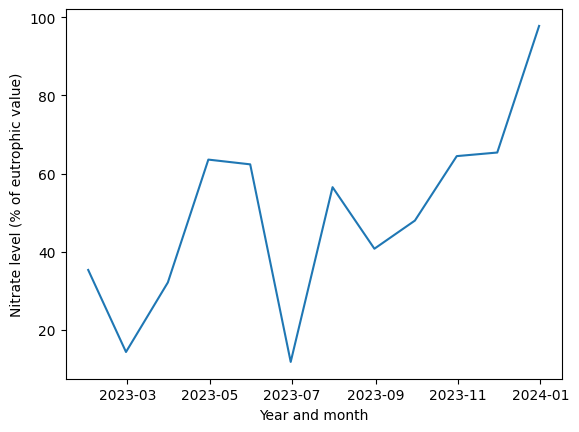

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_883/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

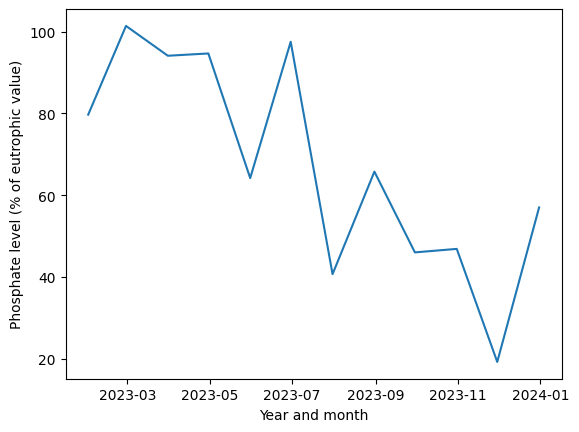

In [4]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

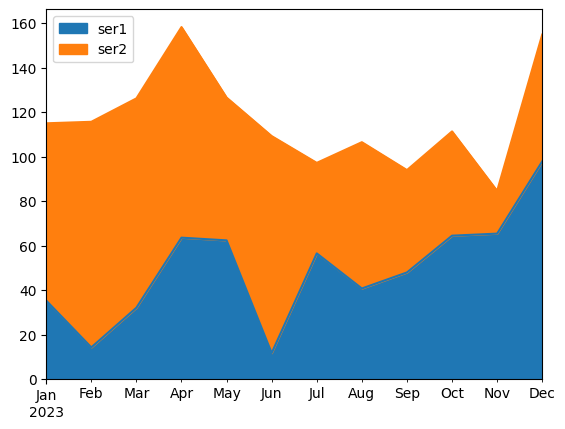

In [5]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

## Answer

### Area plot pros
#### The area plot is more visually impactful and helps to convey the total nutrient load at a glance. Stacking the values can visually emphasize the cumulative effects of nutrients over time, which is useful in environmental study contexts. I think they also saved space by combining both variables into one chart. This format is especially good for communicating seasonal trends and general increases/decreases in combined nutrient levels. This graph enhances storytelling by showing how one variable contributes to a whole system - it shows how different variables can be interconnected.

### Area plot cons
#### The stacked area chart can be misleading when the audience tries to interpret individual values, especially for the top stack. It’s difficult to see independent trends or identify if one nutrient spiked while the other dipped. The audience has to subtract one from the other to isolate one of the levels, which is burdensome. The colors aren't explained - the chart only says "Ser1" or "Ser2", so the data can be misinterpreted. It's a more visually dense chart, but it sacrifices clarity for this.

### Line plot pros
#### The line grapsh clearly show individual trends for nitrate and phosphate without overlap. The lines make it easy to track changes, identify peaks, and view the trend of each nutrient over time. It uses consistent axes and nice colors and simple style. It allows for direct comparisons between variables. This format is especially good for scientific audiences who like precision. Each graph can be annotated independently to highlight the important points if needed.

### Line plot cons
#### Using two separate line plots can fragment the story and require viewers to jump back and forth between the two graphs to compare the data. It takes more vertical space on a page, and can reduce the impact compared to the stacked chart. Comparing exact timings between the nutrients becomes less obvious. Without alignment or visual cues, it's easy for small, important correlations to be missed. It can be improved if both the line charts were combined onto the same graph without stacking.



# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

# Loading Datasets

In [38]:
# Download the datasets
olist_dataset_link = "olistbr/brazilian-ecommerce"
vgrecs_dataset_link = "antonkozyriev/game-recommendations-on-steam"
vgsales_dataset_link = "ashaheedq/video-games-sales-2019"

olist_path = kagglehub.dataset_download(olist_dataset_link)
vgrec_path = kagglehub.dataset_download(vgrecs_dataset_link)
vgsales_path = kagglehub.dataset_download(vgsales_dataset_link)


KaggleApiHTTPError: 403 Client Error.

You don't have permission to access resource at URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.

In [39]:
# Load Video Game Sales data
vgsales_df_raw = pd.read_csv(os.path.join(vgsales_path, "vgsales-12-4-2019-short.csv"))
vgsales_df_cleaned = vgsales_df_raw.dropna(subset=["Year"])
vgsales_df_cleaned["ESRB_Rating"] = vgsales_df_cleaned["ESRB_Rating"].fillna("RP")
vgsales_df_cleaned["Developer"] = vgsales_df_cleaned["Developer"].fillna("Unknown")
sales_cols = ["Global_Sales", "NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"]
vgsales_df_cleaned[sales_cols] = vgsales_df_cleaned[sales_cols].fillna(0)
vgsales_df_cleaned = vgsales_df_cleaned[vgsales_df_cleaned["Year"] <= 2025]
regional_sum = vgsales_df_cleaned[["NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"]].sum(axis=1)
vgsales_df_cleaned = vgsales_df_cleaned[vgsales_df_cleaned["Global_Sales"] >= regional_sum]
vgsales_df_cleaned = vgsales_df_cleaned.drop(columns=["Total_Shipped"])

# Impute null score values with median
# vgsales_df_cleaned['Critic_Score'] = vgsales_df_cleaned['Critic_Score'].fillna(vgsales_df_cleaned['Critic_Score'].median())
# vgsales_df_cleaned['User_Score'] = vgsales_df_cleaned['User_Score'].fillna(vgsales_df_cleaned['User_Score'].median())


# Encode Video Game Sales
vgsales_df_cleaned_encoded = vgsales_df_cleaned.copy()
vgsales_df_cleaned_encoded = pd.get_dummies(vgsales_df_cleaned_encoded, columns=["Genre", "ESRB_Rating"], prefix=["Genre", "ESRB"])
top_platforms = vgsales_df_cleaned_encoded["Platform"].value_counts().nlargest(10).index
vgsales_df_cleaned_encoded["Platform"] = vgsales_df_cleaned_encoded["Platform"].where(vgsales_df_cleaned_encoded["Platform"].isin(top_platforms), other="Other")
vgsales_df_cleaned_encoded = pd.get_dummies(vgsales_df_cleaned_encoded, columns=["Platform"], prefix="Platform")
for col in ["Publisher", "Developer"]:
    freq_map = vgsales_df_cleaned_encoded[col].value_counts(normalize=True)
    vgsales_df_cleaned_encoded[col + "_freq"] = vgsales_df_cleaned_encoded[col].map(freq_map)
vgsales_df_cleaned_encoded = vgsales_df_cleaned_encoded.drop(columns=["Publisher", "Developer"])

/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_883/4200982045.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vgsales_df_cleaned["ESRB_Rating"] = vgsales_df_cleaned["ESRB_Rating"].fillna("RP")
/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_883/4200982045.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vgsales_df_cleaned["Developer"] = vgsales_df_cleaned["Developer"].fillna("Unknown")
/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_883/4200982045.py:7: SettingWithCo

In [ ]:
# Load Video Game Recommendations data
vgrecs_recs_df_raw = pd.read_csv(os.path.join(vgrec_path, "recommendations.csv"))
vgrecs_users_df_raw = pd.read_csv(os.path.join(vgrec_path, "users.csv"))
vgrecs_games_df_raw = pd.read_csv(os.path.join(vgrec_path, "games.csv"))
vgrecs_game_metadata_path = os.path.join(vgrec_path, "games_metadata.json")
meta_df = pd.read_json(vgrecs_game_metadata_path, lines=True)


vgrecs_merged_df = vgrecs_recs_df_raw.merge(vgrecs_users_df_raw, on="user_id", how="left")
vgrecs_merged_df = vgrecs_merged_df.merge(vgrecs_games_df_raw, on="app_id", how="left")
vgrecs_merged_df["date_release"] = pd.to_datetime(vgrecs_merged_df["date_release"], errors="coerce")

# keep only app_id + first tag = genre
tag_lookup = (
    meta_df
      .assign(genre=lambda d: d["tags"].str[0])
      .loc[:, ["app_id", "genre"]]
      .drop_duplicates("app_id")
)

vgrecs_merged_df = vgrecs_merged_df.merge(tag_lookup, on="app_id", how="left")
vgrecs_merged_df["genre"] = vgrecs_merged_df["genre"].fillna("No Category")

print(f"Raw: {vgrecs_merged_df.shape}")
# cut data in quarter because it is too large for my kernel
vgrecs_merged_df = vgrecs_merged_df.sample(frac=0.10, random_state=42)
# remove anything with price over 175, it makes no sense to unneccesarily distort games
vgrecs_merged_df = vgrecs_merged_df[vgrecs_merged_df["price_final"] <= 175]

print(f"Cleaned: {vgrecs_merged_df.shape}")

# clean up the unused dataframes
del vgrecs_recs_df_raw
del vgrecs_users_df_raw
del vgrecs_games_df_raw
del meta_df
gc.collect()

# Encode Video Game Recommendations
# vgrecs_merged_df_encoded = vgrecs_merged_df.copy()
# rating_order = ['Overwhelmingly Negative', 'Very Negative', 'Mostly Negative', 'Negative', 'Mixed', 'Positive', 'Mostly Positive', 'Very Positive', 'Overwhelmingly Positive']
# rating_map = {label: idx for idx, label in enumerate(rating_order)}
# vgrecs_merged_df_encoded['rating_encoded'] = vgrecs_merged_df_encoded['rating'].map(rating_map)

In [75]:
# Load Olist datasets
olist_products_df_raw = pd.read_csv(os.path.join(olist_path, "olist_products_dataset.csv"))
olist_translation_df_raw = pd.read_csv(os.path.join(olist_path, "product_category_name_translation.csv"))
olist_reviews_df_raw = pd.read_csv(os.path.join(olist_path, "olist_order_reviews_dataset.csv"))
olist_orders_df_raw = pd.read_csv(os.path.join(olist_path, "olist_orders_dataset.csv"))
olist_customers_df_raw = pd.read_csv(os.path.join(olist_path, "olist_customers_dataset.csv"))
olist_items_df_raw = pd.read_csv(os.path.join(olist_path, "olist_order_items_dataset.csv"))

# Merge Olist data
olist_products_df = olist_products_df_raw.merge(olist_translation_df_raw, how="left", on="product_category_name")
olist_order_lines_df = olist_items_df_raw.merge(olist_products_df, how="left", on="product_id")
olist_order_lines_df = olist_order_lines_df.merge(olist_orders_df_raw[["order_id", "customer_id", "order_purchase_timestamp"]], how="left", on="order_id")
olist_order_lines_df = olist_order_lines_df.merge(olist_customers_df_raw[["customer_id", "customer_unique_id", "customer_state"]], how="left", on="customer_id")
olist_merged_df = olist_order_lines_df.merge(olist_reviews_df_raw[["order_id", "review_score", "review_creation_date", "review_answer_timestamp"]], how="left", on="order_id")

# Clean Olist
olist_cleaned_df = olist_merged_df.drop_duplicates()
olist_cleaned_df = olist_cleaned_df.dropna(subset=["product_category_name", "product_category_name_english", "review_score", "product_weight_g"])
olist_cleaned_df["review_creation_date"] = pd.to_datetime(olist_cleaned_df["review_creation_date"])
olist_cleaned_df["order_purchase_timestamp"] = pd.to_datetime(olist_cleaned_df["order_purchase_timestamp"])
olist_cleaned_df["days_to_review"] = olist_cleaned_df["review_creation_date"] - olist_cleaned_df["order_purchase_timestamp"]
olist_cleaned_df = olist_cleaned_df[olist_cleaned_df["days_to_review"] >= pd.Timedelta(0)]
olist_cleaned_df = olist_cleaned_df.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length"
})
olist_cleaned_df['order_purchase_timestamp'] = pd.to_datetime(olist_cleaned_df['order_purchase_timestamp'], errors='coerce')
olist_cleaned_df['shipping_limit_date'] = pd.to_datetime(olist_cleaned_df['shipping_limit_date'], errors='coerce')
olist_cleaned_df = olist_cleaned_df.drop(columns=["product_category_name"])

# Encode Olist
olist_cleaned_encoded_df = olist_cleaned_df.drop(columns=[
    "order_id", "customer_id", "product_id", "seller_id", "customer_unique_id",
    "review_creation_date", "shipping_limit_date", "review_answer_timestamp"
])
olist_cleaned_encoded_df = pd.get_dummies(olist_cleaned_encoded_df, columns=["product_category_name_english", "customer_state"])
olist_cleaned_encoded_df["days_to_review"] = olist_cleaned_encoded_df["days_to_review"].dt.total_seconds() / 86400


# Video Game Sales Dataset

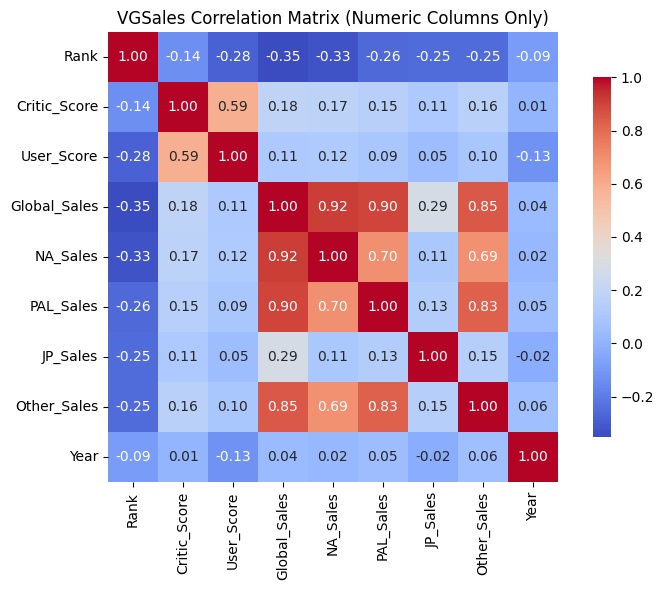

In [9]:
# Examine correlation matrix

vgsales_numeric_df = vgsales_df_cleaned.select_dtypes(include='number')
corr_matrix = vgsales_numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title("VGSales Correlation Matrix (Numeric Columns Only)")
plt.tight_layout()
plt.show()

### The regional sales metrics are all strongly correlated with the global sales, which makes sense because global sales are a sum of the regional sales. The rank is also inversely correlated with the sales, which makes sense because the game's sales and popularity is an indicator of the rank (lower number, higher rank). However, there is little intercorrelation between any other columns.

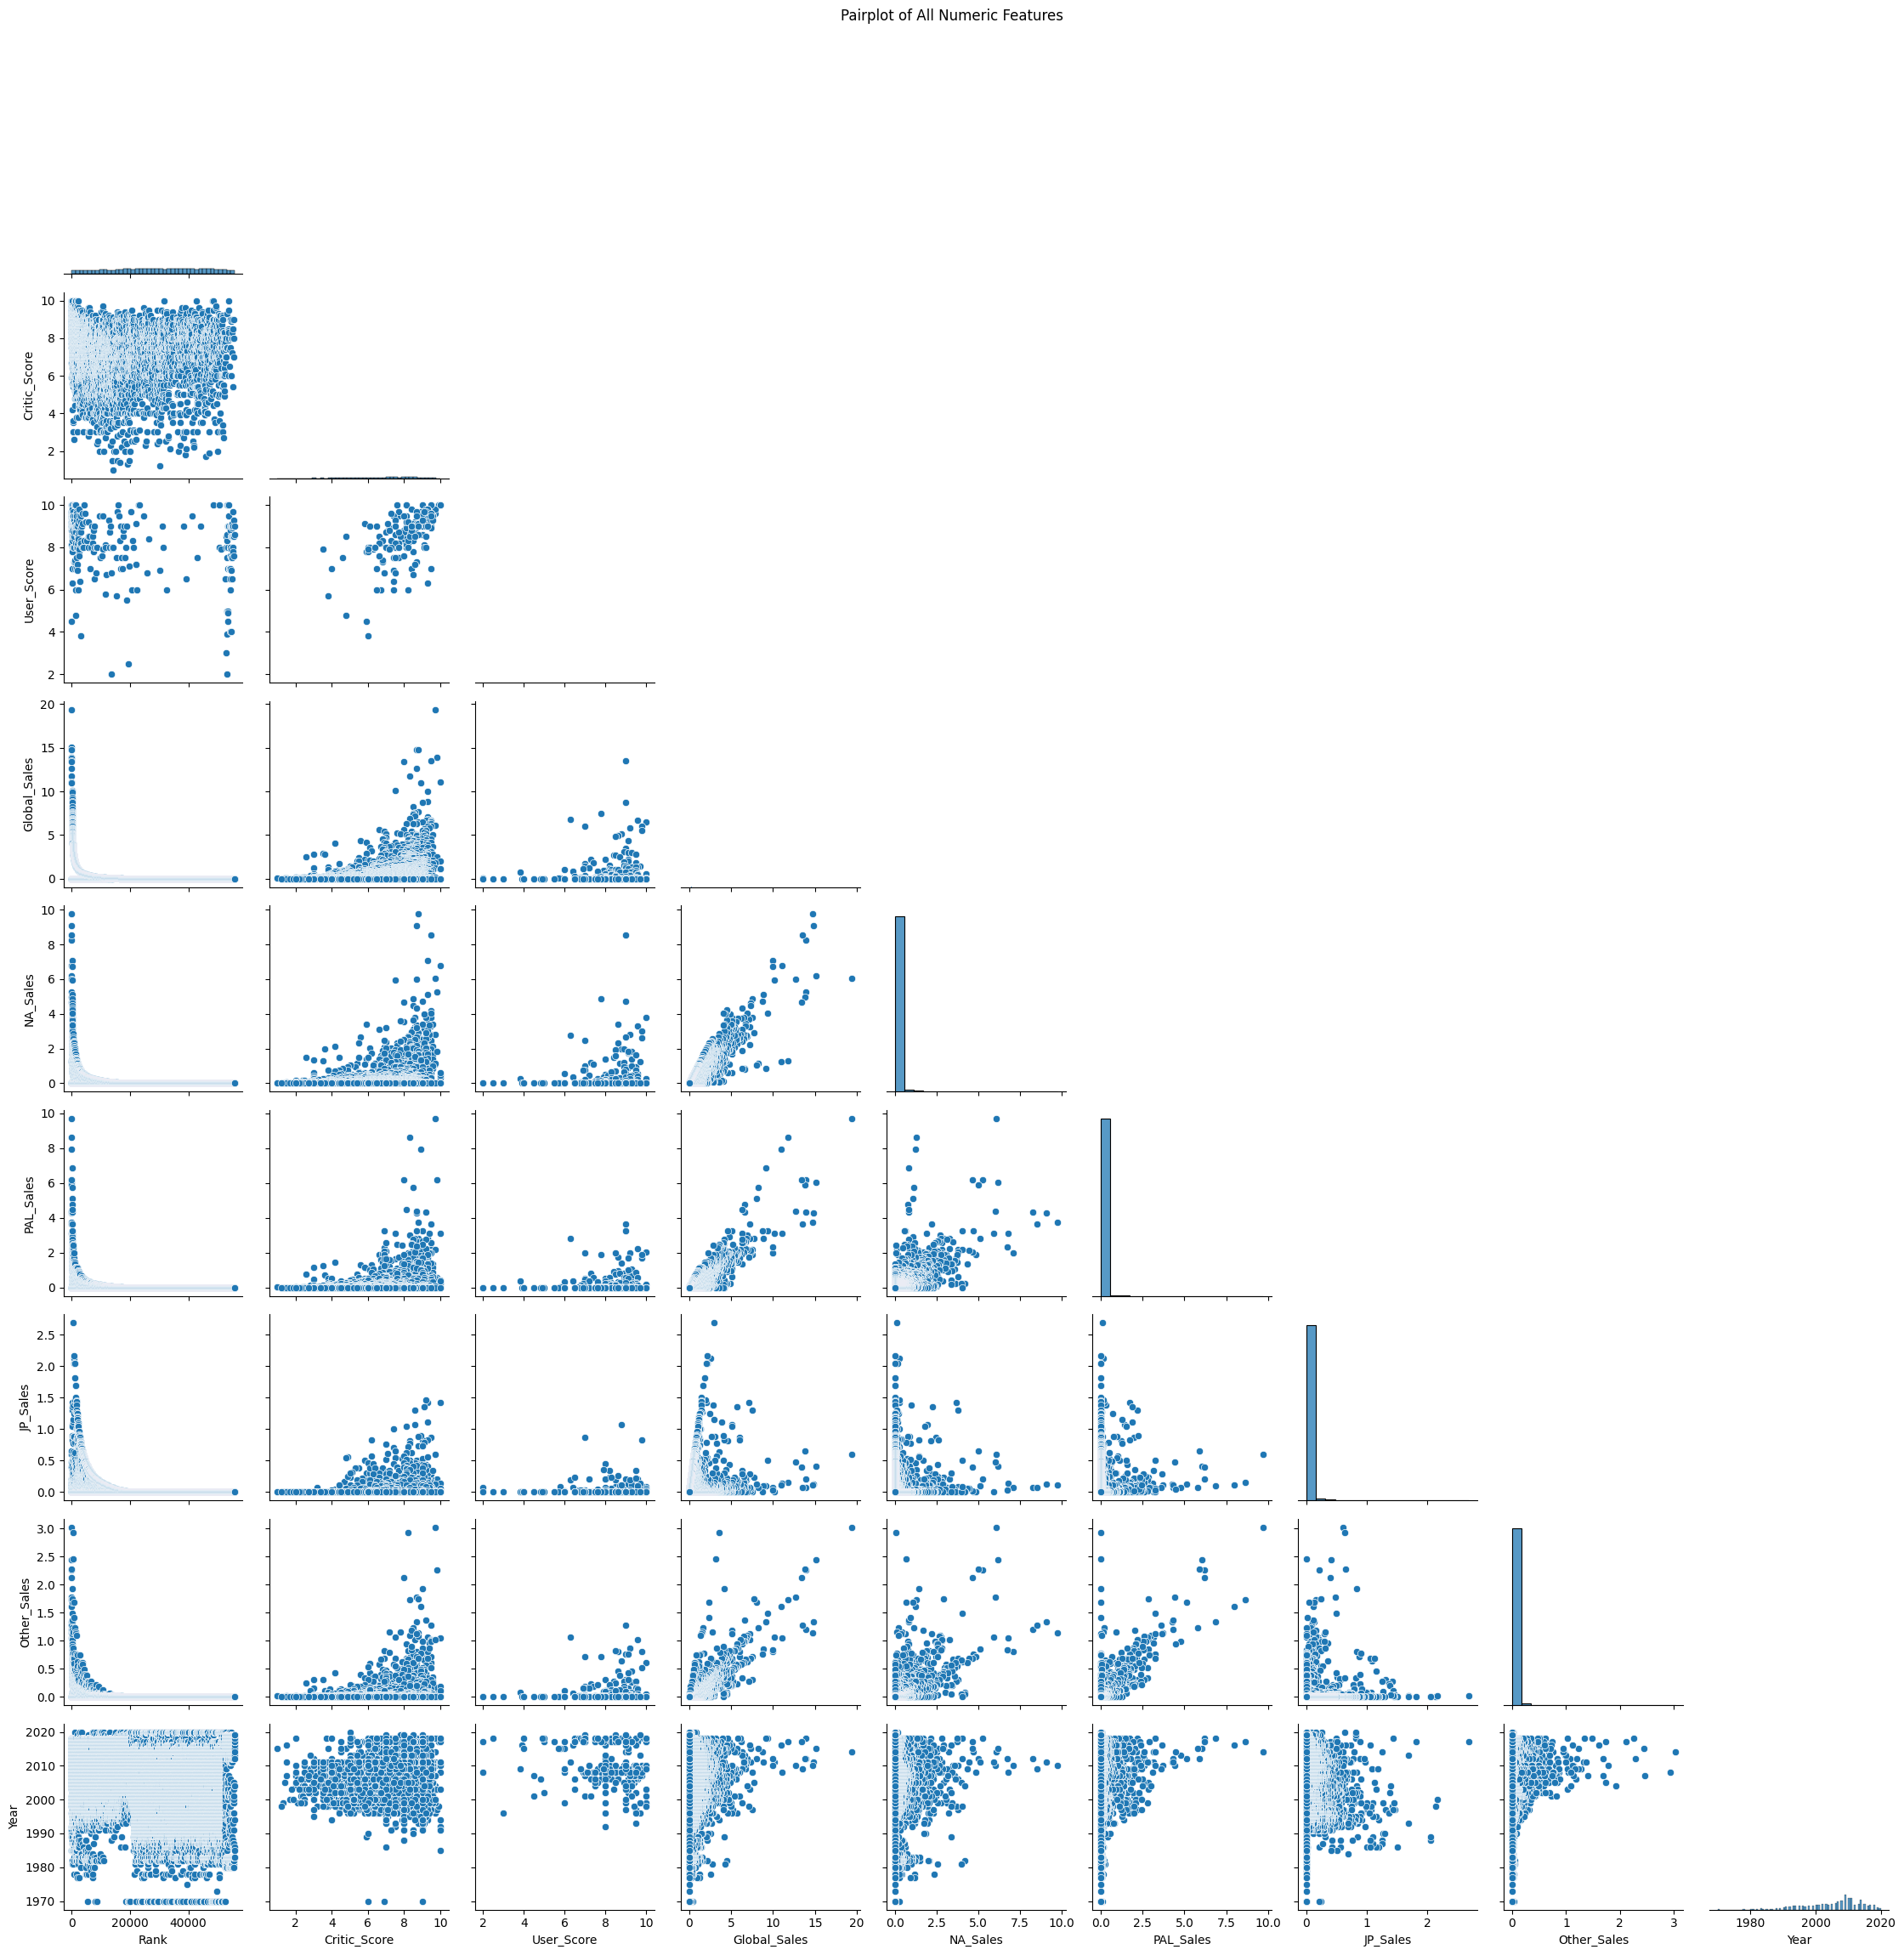

In [10]:
# Draw Pairplots
sns.pairplot(vgsales_numeric_df, corner=True)
plt.suptitle("Pairplot of All Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

### This pairplot identifies a lot of the correlations we already knew - the sales numbers are all well-correlated to one another. 

### The User score vs rank plot shows us that there is a distinct line of points going down the right side of the chart (high rank value = poorly ranked). This might mean that while there are some poorly ranked games, their user scores may be a mixed bag. However, most of the data points are at the top left of this chart, indicating that highly-ranked games are generally associated with high critic scores, meaning that user-score can be a predictor of popularity.

### User score and critic scores colocalize highly, telling us that they can generally agree on good games, but the scores can vary on games with lower scores. This makes sense why there is a moderate correlation between the two features, but not exactly a linear relationship.

### While there isn't a direct linear relationship, we can see that there is a similar pattern between the regional sales and the critic scores/user scores. Higher scores are associated with higher sales. 

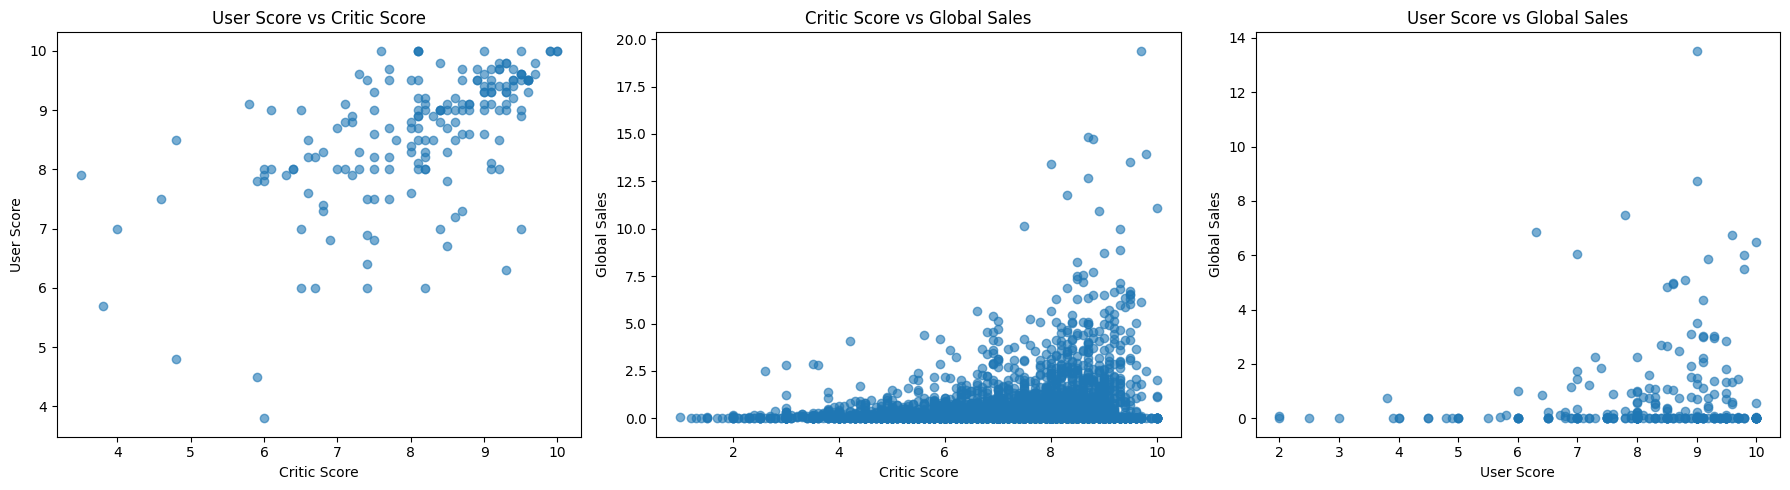

In [11]:
# Identify scatterplots with highly correlated variables

# set up subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: User Score vs Critic Score
axs[0].scatter(vgsales_df_cleaned['Critic_Score'], vgsales_df_cleaned['User_Score'], alpha=0.6)
axs[0].set_xlabel('Critic Score')
axs[0].set_ylabel('User Score')
axs[0].set_title('User Score vs Critic Score')

# Scatter: Critic Score vs Global Sales
axs[1].scatter(vgsales_df_cleaned['Critic_Score'], vgsales_df_cleaned['Global_Sales'], alpha=0.6)
axs[1].set_xlabel('Critic Score')
axs[1].set_ylabel('Global Sales')
axs[1].set_title('Critic Score vs Global Sales')

# Scatter: User Score vs Global Sales
axs[2].scatter(vgsales_df_cleaned['User_Score'], vgsales_df_cleaned['Global_Sales'], alpha=0.6)
axs[2].set_xlabel('User Score')
axs[2].set_ylabel('Global Sales')
axs[2].set_title('User Score vs Global Sales')

plt.tight_layout()
plt.show()


### User Score Vs Critic Score tells us that while the lower-scored video games have varying user/critic opinions, many games with high scores (>8) will have user scores and critic scores that are roughly the same value.
### Critic Score Vs Global Sales: While a lot of the global sales values lie around 0, there is a pattern that shows us that higher critic scores are associated with higher sales numbers.
### User Score Vs Global Sales Score: Similar to the previous chart, we can see that there is a pattern of high user scores associated with higher sales numbers.

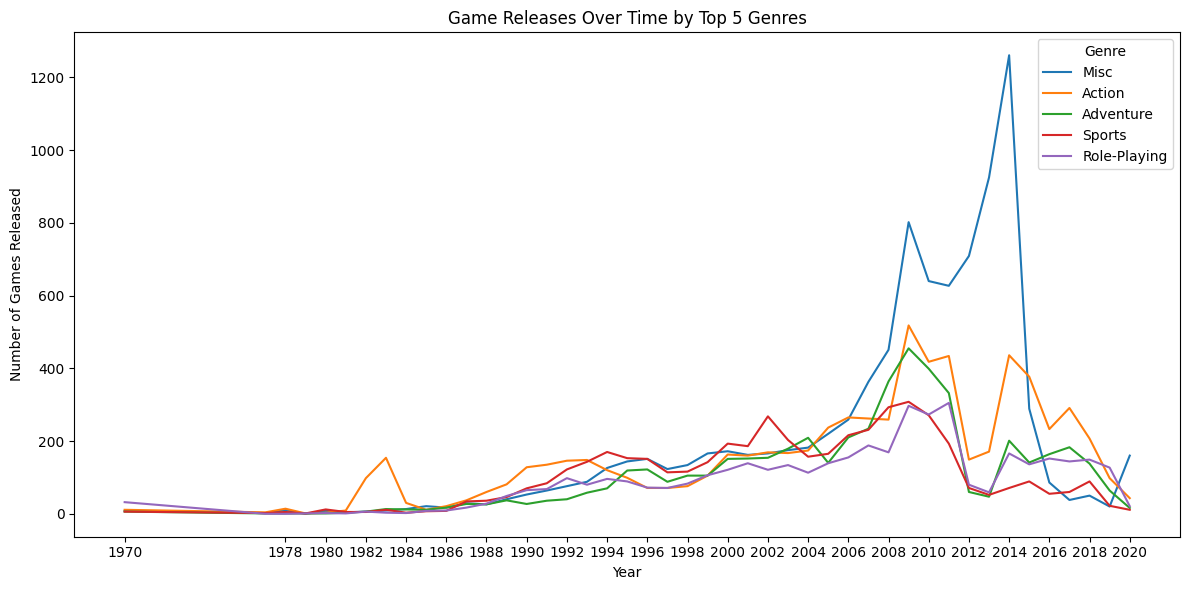

In [13]:
# Are there any game genres that are getting more popular?
# group games by year and make multi-line chart of how many games of top 5 genres genres were released in past years

# crop rows where Year or Genre is missing
df = vgsales_df_cleaned.dropna(subset=['Year', 'Genre'])

# convert year to integer if it's float
df['Year'] = df['Year'].astype(int)

# count games by Genre
top_genres = df['Genre'].value_counts().nlargest(5).index

# filter for top 5 genres
df_top_genres = df[df['Genre'].isin(top_genres)]

# group by year and genre, count releases
genre_year_counts = df_top_genres.groupby(['Year', 'Genre']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
for genre in top_genres:
    plt.plot(genre_year_counts.index, genre_year_counts[genre], label=genre)

plt.title("Game Releases Over Time by Top 5 Genres")
plt.xlabel("Year")
plt.ylabel("Number of Games Released")
plt.legend(title="Genre")
plt.xticks(ticks=genre_year_counts.index[::2])
plt.tight_layout()
plt.show()


### We can see that all game genres are relatively popular up until 2008, where the "MISC" genre takes over as having the most games released per year. After the MISC game popularity starts to die down around 2014, Action games become the most released game per year until roughly 2019.

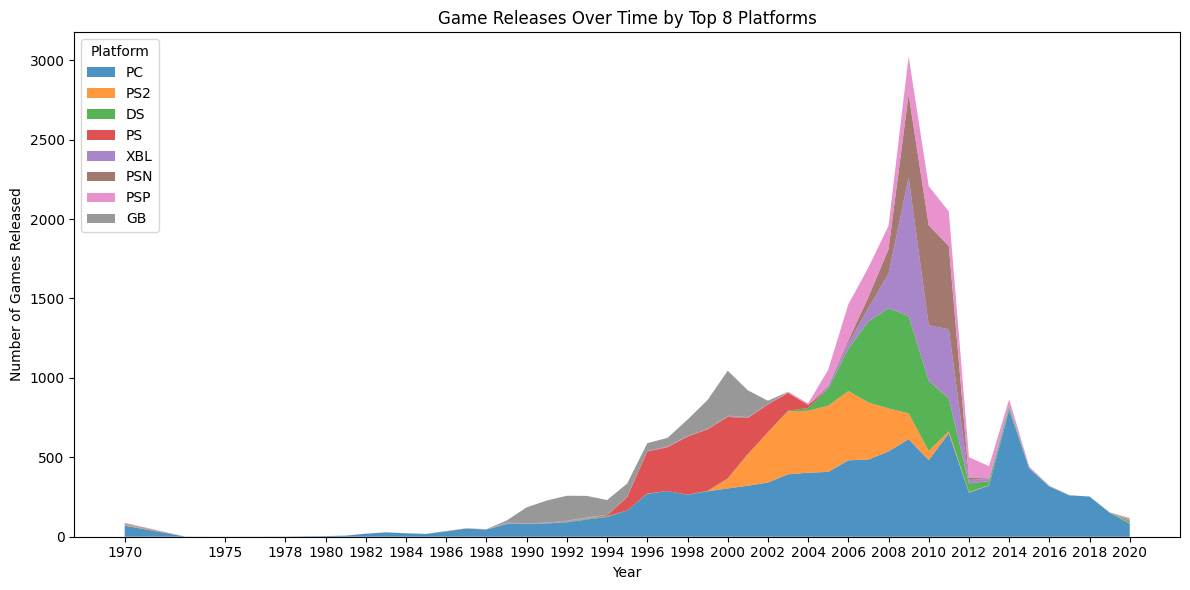

In [14]:
# Are any particular platforms getting more or less popular over time?
# group games by year and make multi-line chart of how many games of top 5 platforms were released in past years

# Drop rows where Year or Platform is missing
df = vgsales_df_cleaned.dropna(subset=['Year', 'Platform'])
df['Year'] = df['Year'].astype(int)

# Get top 5 platforms by total number of games
top_platforms = df['Platform'].value_counts().nlargest(8).index

# Filter to include only top platforms
df_top_platforms = df[df['Platform'].isin(top_platforms)]

# Group by Year and Platform, count number of games
platform_year_counts = df_top_platforms.groupby(['Year', 'Platform']).size().unstack(fill_value=0)

# Sort by year to ensure proper plotting
platform_year_counts = platform_year_counts.sort_index()

# Plot area chart
plt.figure(figsize=(12, 6))
plt.stackplot(
    platform_year_counts.index,
    [platform_year_counts[platform] for platform in top_platforms],
    labels=top_platforms,
    alpha=0.8
)

plt.title("Game Releases Over Time by Top 8 Platforms")
plt.xlabel("Year")
plt.ylabel("Number of Games Released")

# Show x-axis ticks every 2 years
plt.xticks(ticks=platform_year_counts.index[::2])

plt.legend(title="Platform", loc='upper left')
plt.tight_layout()
plt.show()


### This chart reveals that game releases peaked sharply around 2008–2010, driven by platforms like PC, PS2, DS, and digital storefronts like PSN (Play station network). PC stands out with the most consistent and long-lasting release activity across decades. Handheld systems like DS and PSP show intense but brief bursts of activity, while older platforms like Game Boy faded by the early 2000s. After 2011, there is a steep decline in releases across all platforms, possibly due to shifts in industry trends or dataset limitations. Overall, the chart captures the rise and fall of platform dominance and underscores PC’s enduring role in the gaming ecosystem.

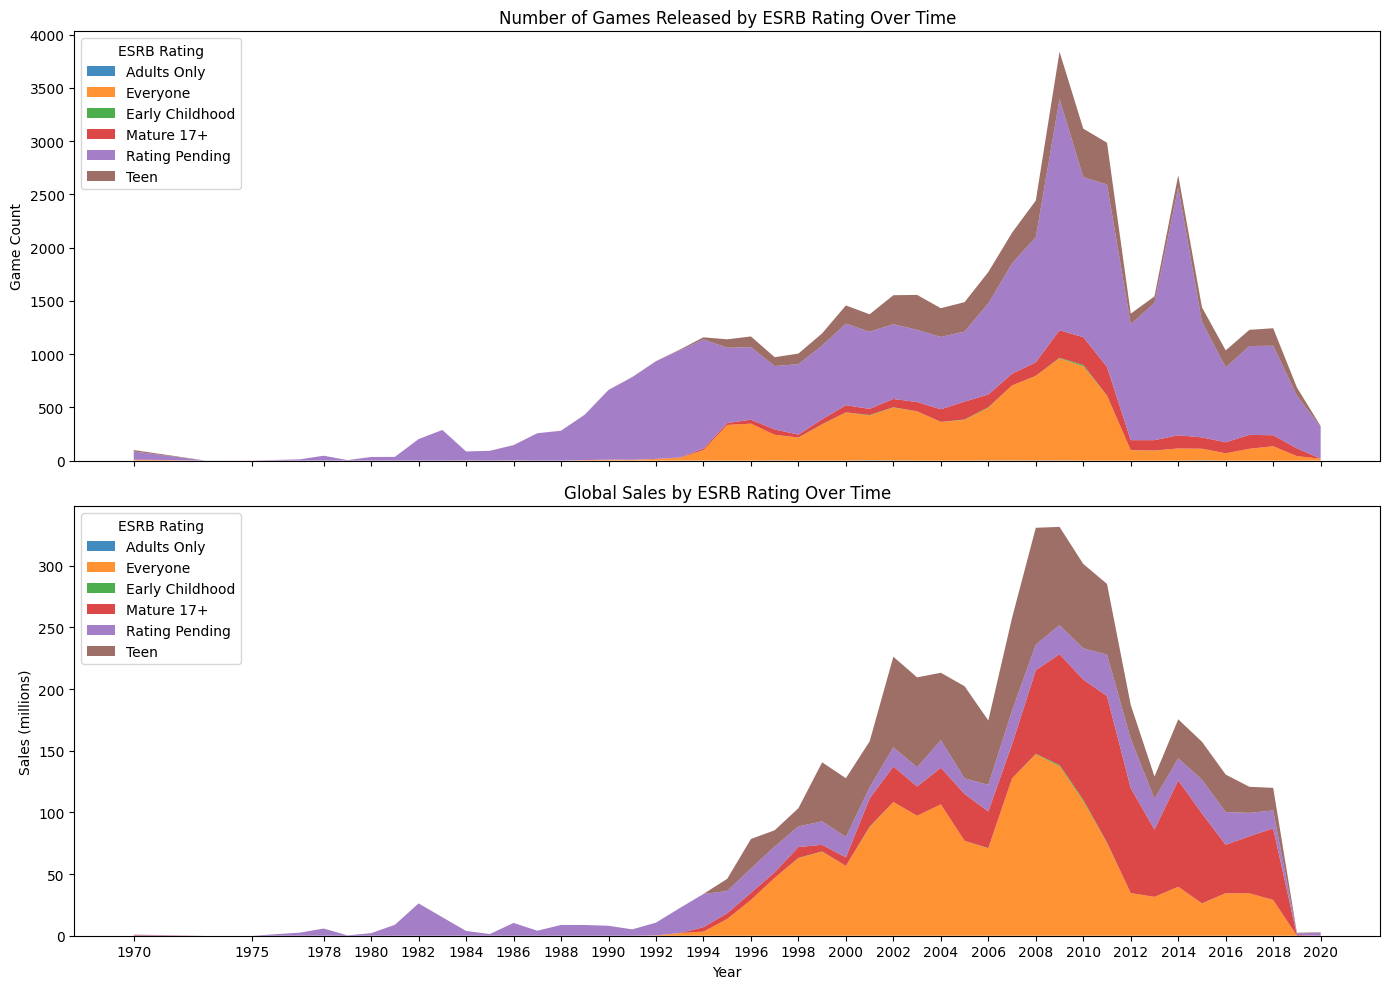

In [15]:
# ESRB rating over time + ESRB Sales over time

# Clean data
df = vgsales_df_cleaned.dropna(subset=['Year', 'ESRB_Rating', 'Global_Sales'])
df['Year'] = df['Year'].astype(int)

# Define mapping from ESRB code to full name
esrb_label_map = {
    'EC': 'Early Childhood',
    'E': 'Everyone',
    'E10+': 'Everyone 10+',
    'T': 'Teen',
    'M': 'Mature 17+',
    'AO': 'Adults Only',
    'RP': 'Rating Pending'
}

# Filter to only ratings in map
df = df[df['ESRB_Rating'].isin(esrb_label_map.keys())]

# Group data
esrb_count_by_year = df.groupby(['Year', 'ESRB_Rating']).size().unstack(fill_value=0).sort_index()
esrb_sales_by_year = df.groupby(['Year', 'ESRB_Rating'])['Global_Sales'].sum().unstack(fill_value=0).sort_index()

# Prepare full labels for plots
mapped_labels = [esrb_label_map[r] for r in esrb_count_by_year.columns]

# Plot
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Game count
axs[0].stackplot(
    esrb_count_by_year.index,
    [esrb_count_by_year[r] for r in esrb_count_by_year.columns],
    labels=mapped_labels,
    alpha=0.85
)
axs[0].set_title("Number of Games Released by ESRB Rating Over Time")
axs[0].set_ylabel("Game Count")
axs[0].legend(title="ESRB Rating", loc='upper left')
axs[0].set_xticks(ticks=esrb_count_by_year.index[::2])

# Subplot 2: Global sales
axs[1].stackplot(
    esrb_sales_by_year.index,
    [esrb_sales_by_year[r] for r in esrb_sales_by_year.columns],
    labels=mapped_labels,
    alpha=0.85
)
axs[1].set_title("Global Sales by ESRB Rating Over Time")
axs[1].set_xlabel("Year")
axs[1].set_ylabel("Sales (millions)")
axs[1].legend(title="ESRB Rating", loc='upper left')
axs[1].set_xticks(ticks=esrb_sales_by_year.index[::2])

plt.tight_layout()
plt.show()


### This chart shows that "Teen" and "Everyone" rated games have consistently dominated both in terms of release count and global sales, especially during the 2000s. "Mature 17+" games, while there are fewer, contributed significantly to global revenue between 2005 and 2012, indicating high commercial success per title. "Rating Pending" appears disproportionately in release counts, probablly because of early listings or incomplete metadata, but doesn't contribue much to global sales. "Adults Only" and "Early Childhood" categories had almost no impact on the market, both in volume and revenue. Overall, the data suggests that family-friendly and teen-targeted games have been the industry's safest and most profitable bet over the past few decades.

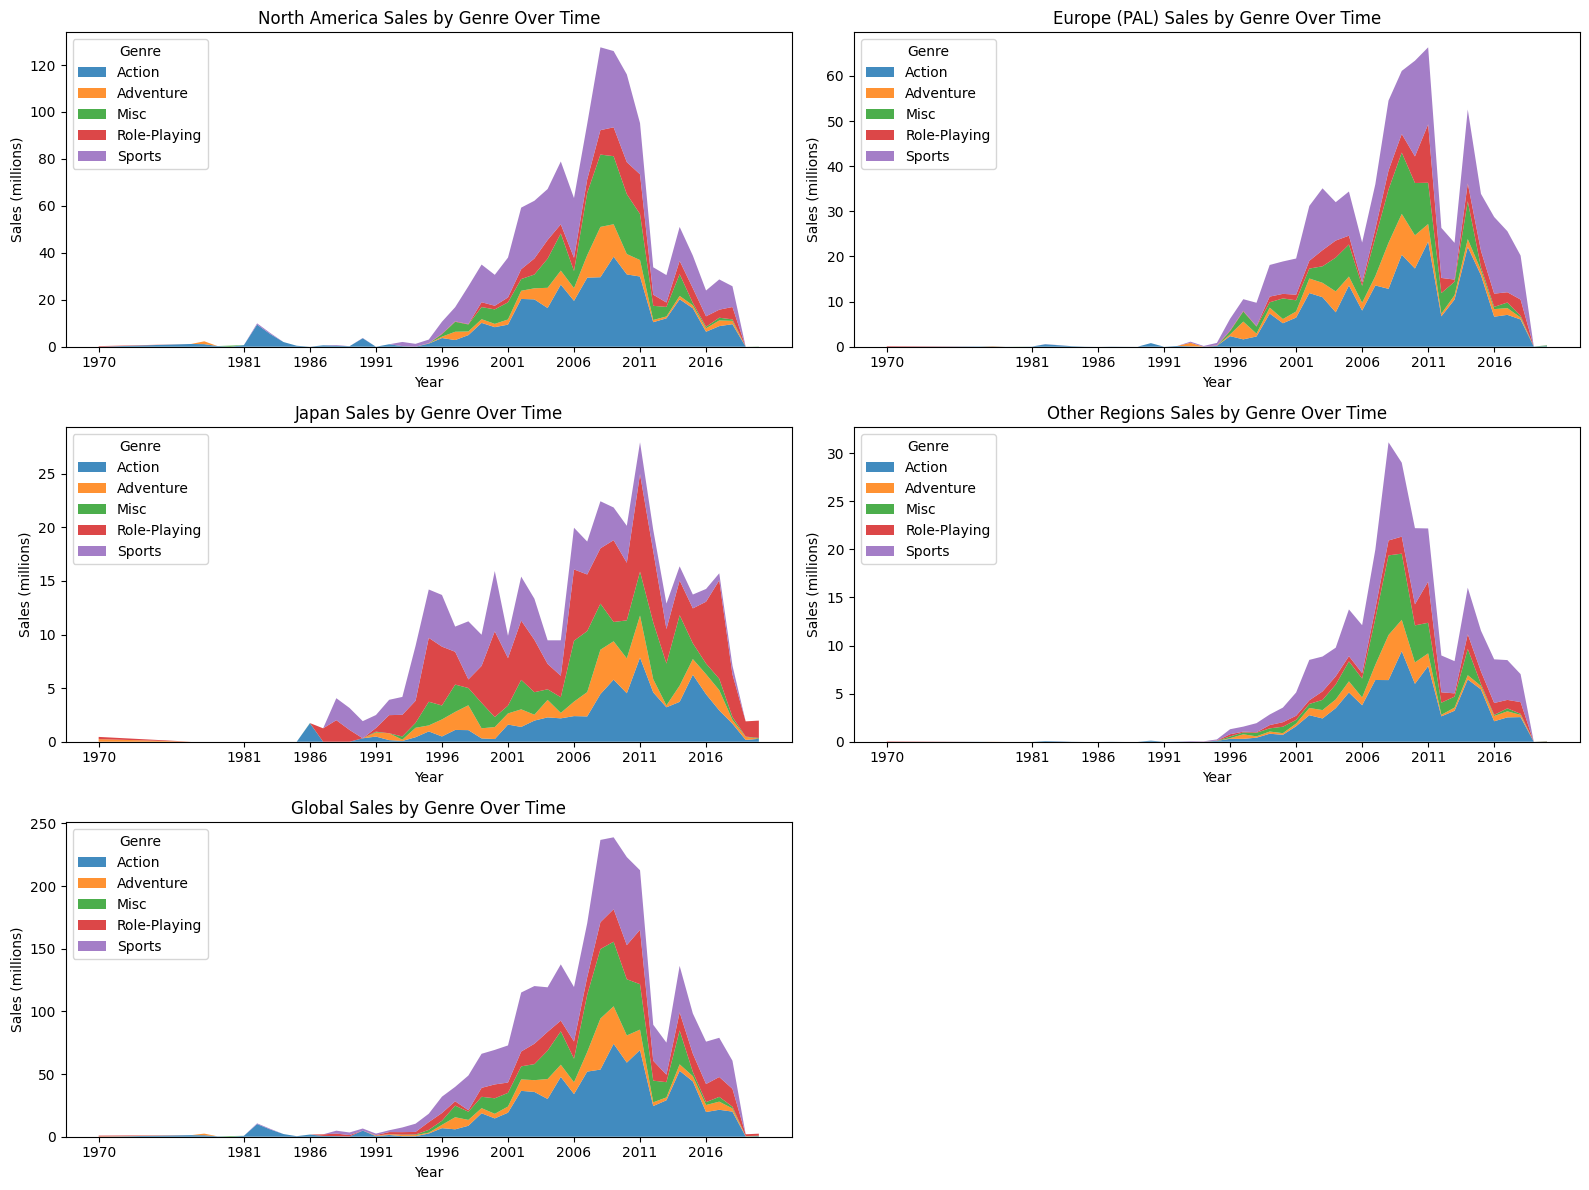

In [16]:
# Regional sales subplots over time grouped by genre

# Clean data
df = vgsales_df_cleaned.dropna(subset=['Year', 'Genre', 'NA_Sales', 'PAL_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'])
df['Year'] = df['Year'].astype(int)

# Optional: focus on top genres
top_genres = df['Genre'].value_counts().nlargest(5).index
df = df[df['Genre'].isin(top_genres)]

# Define region + global sales mapping
region_sales = {
    'NA_Sales': 'North America',
    'PAL_Sales': 'Europe (PAL)',
    'JP_Sales': 'Japan',
    'Other_Sales': 'Other Regions',
    'Global_Sales': 'Global'
}

# Setup 3x2 subplot grid
fig, axs = plt.subplots(3, 2, figsize=(16, 12))
axs = axs.flatten()

# Iterate through each region
for idx, (region_col, region_name) in enumerate(region_sales.items()):
    region_df = df.groupby(['Year', 'Genre'])[region_col].sum().unstack(fill_value=0)
    region_df = region_df.sort_index()

    # Area chart for region
    axs[idx].stackplot(region_df.index, [region_df[genre] for genre in region_df.columns], labels=region_df.columns, alpha=0.85)
    axs[idx].set_title(f"{region_name} Sales by Genre Over Time")
    axs[idx].set_xlabel("Year")
    axs[idx].set_ylabel("Sales (millions)")
    axs[idx].set_xticks(region_df.index[::5])
    axs[idx].legend(title="Genre", loc='upper left')

# Remove empty subplot if any
if len(region_sales) < len(axs):
    for idx in range(len(region_sales), len(axs)):
        fig.delaxes(axs[idx])

plt.tight_layout()
plt.show()

### This chart shows us that Action and Sports genres consistently dominated global and regional sales from the early 2000s to around 2010, especially in North America and Europe. Role-Playing games, while globally less dominant, had a stronger and more sustained presence in Japan, indicating a clear regional preference. Sales peaked sharply between 2007 and 2010 across all regions, aligning with the height of the console generation that included the Xbox 360, PS3, and Wii. After 2010, all regions show a marked decline in total genre sales, likely reflecting market saturation or a cutoff in the dataset. Overall, genre popularity was relatively stable within regions, but regional preferences—like Japan’s affinity for RPGs stands out clearly.

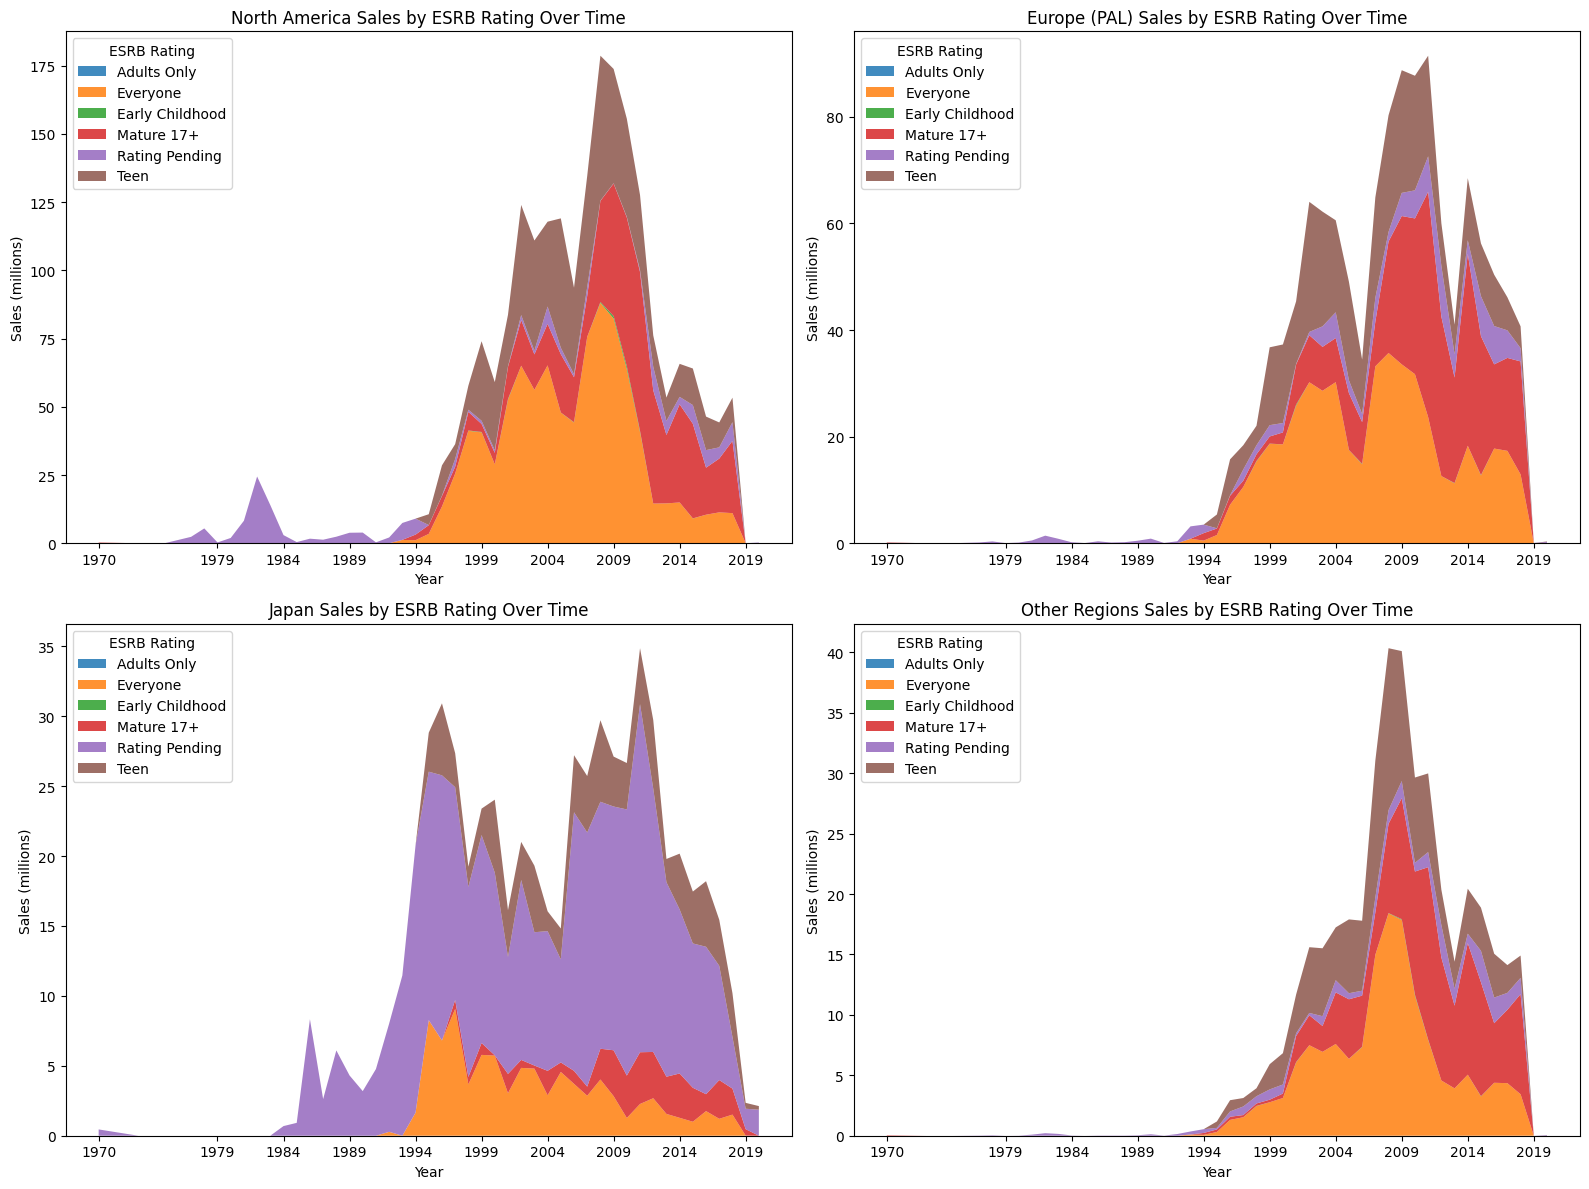

In [17]:
# ESRB Rating compared to regional sales

# Clean and prep data
df = vgsales_df_cleaned.dropna(subset=['Year', 'ESRB_Rating', 'NA_Sales', 'PAL_Sales', 'JP_Sales', 'Other_Sales'])
df['Year'] = df['Year'].astype(int)

# ESRB code to full label mapping
esrb_label_map = {
    'EC': 'Early Childhood',
    'E': 'Everyone',
    'E10+': 'Everyone 10+',
    'T': 'Teen',
    'M': 'Mature 17+',
    'AO': 'Adults Only',
    'RP': 'Rating Pending'
}

# Filter valid ESRB ratings
df = df[df['ESRB_Rating'].isin(esrb_label_map.keys())]

# Define region columns and labels
regions = {
    'NA_Sales': 'North America',
    'PAL_Sales': 'Europe (PAL)',
    'JP_Sales': 'Japan',
    'Other_Sales': 'Other Regions'
}

# Create 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

# Plot for each region
for i, (col, region_title) in enumerate(regions.items()):
    # Group by Year and ESRB Rating, sum sales
    grouped = df.groupby(['Year', 'ESRB_Rating'])[col].sum().unstack(fill_value=0).sort_index()

    # Apply label mapping and reassign column order for consistent colors
    labels = [esrb_label_map[r] for r in grouped.columns]
    data = [grouped[r] for r in grouped.columns]

    # Plot stacked area chart
    axs[i].stackplot(grouped.index, data, labels=labels, alpha=0.85)
    axs[i].set_title(f"{region_title} Sales by ESRB Rating Over Time")
    axs[i].set_xlabel("Year")
    axs[i].set_ylabel("Sales (millions)")
    axs[i].set_xticks(grouped.index[::5])
    axs[i].legend(title="ESRB Rating", loc='upper left')

plt.tight_layout()
plt.show()


### This chart shows that "Teen" and "Everyone" rated games consistently led sales across all regions, with "Mature 17+" titles contributing significantly in North America and Europe but less so in Japan. Japan's sales were heavily skewed toward Teen-rated games, with minimal "Mature" rated impact, unlike the West. The spike in sales between 2005–2010 is visible across all regions, highlighting a global boom during that console generation. "Adults Only" and "Early Childhood" ratings had negligible sales impact worldwide.

# Video Game Sales Conclusions

## Conclusions
### The dataset appears to be and mostly usable, with consistent trends across regions, genres, ESRB ratings, and sales data. The relationships such as higher global sales for games with high critic scores or the dominance of Teen and Everyone-rated titles are mostly expected and align with industry norms. However, there are signs of incomplete or truncated data after around 2012, possibly because of data collection cutoffs, which may limit time-based comparisons for recent years. The data is highly usable for analyzing historical trends and making comparative inferences across regions, genres, or rating categories.

## Outliers
### The scatter plots reveal dense clustering near zero sales but with a few extreme outliers - e.g. games with unusually high global sales exceeding 15 million units. These are likely blockbuster titles like "Wii Sports" or "GTA V", and while they are real, they can distort regression or average-based analyses. User score vs. global sales also shows many games with relatively low scores but non-zero sales, suggesting anomalies like critically panned games that still sold well (possibly due to marketing or IP recognition). The distribution of game counts in the ESRB "Rating Pending" category is also suspiciously high, especially in early years, which may indicate missing or placeholder values.

## Highly Correlated Variables
### The heatmap shows very high correlations between Global_Sales and regional sales (NA_Sales, PAL_Sales, Other_Sales), especially NA and PAL. This is expected because global sales are a sum of these components, making them mathematically redundant for most modeling purposes.

## Time-Based Trends
### Almost all line and area charts show a clear boom from 2005–2010, followed by a dramatic decline in releases and sales. This pattern is visible in platform popularity, genre distribution, and ESRB sales, hinting at something like industry saturation, shift to digital/mobile gaming, or dataset incompleteness after 2012.
### This drift means any time-based analysis must be bounded or normalized, as comparing pre-2010 and post-2010 data directly may introduce bias. For instance, sales or rating trends may appear to change simply due to data drop-off rather than actual industry behavior.

## Possible Confounding Variables
### Several confounding variables are likely causing these trends:
### - Marketing budget or franchise recognition can influence both scores (user/critic) and sales but are not denoted in the dataset.
### - Platform lifecycle may affect both genre availability and sales (e.g., RPGs peaking on DS/PSP).
### - Region-specific release strategies (like limited JP launches) could distort the correlation between rating, genre, and regional sales.
### - Online vs. physical distribution - which changed rapidly in the 2010s like with the PSN - is not captured but could strongly confound platform and sales trends.

# Video Game Recommendations Dataset

In [ ]:
# Examine correlation matrix

numeric_df = vgrecs_merged_df[[
    'helpful',
    'funny',
    'hours',
    'products',
    'reviews',
    'positive_ratio',
    'user_reviews',
    'price_final',
    'price_original',
    'discount'
]]

# encode is recommended
numeric_df['is_recommended'] = vgrecs_merged_df['is_recommended'].astype(int)
# encode sentiment 
sentiment_map = {
    'Overwhelmingly Positive': 5,
    'Very Positive': 4,
    'Mostly Positive': 3,
    'Mixed': 2,
    'Mostly Negative': 1,
    'Very Negative': 0
}
numeric_df['rating_numeric'] = vgrecs_merged_df['rating'].map(sentiment_map)

plt.figure(figsize=(10, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix (Numeric Features in Steam Review Dataset)")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

### The correlation matrix shows a strong relationship between the number of helpful and funny votes (r = 0.48), suggesting that users who write engaging reviews tend to get both types of reactions. There is also a high correlation between positive_ratio and rating_numeric (r = 0.91), confirming that Steam’s summary ratings closely mirror the underlying user sentiment distribution. Interestingly, is_recommended shows only moderate correlation with either positive_ratio (r = 0.33) or rating_numeric (r = 0.29), implying that individual recommendations may not always align perfectly with their review scores.

In [ ]:
# Draw Pairplots

cols = ['helpful', 'funny', 'hours', 'positive_ratio', 'price_final', 'discount']
df_sample = vgrecs_merged_df[cols].dropna().sample(100_000, random_state=42)  # or adjust to 50k–200k

n = len(cols)
fig, axes = plt.subplots(n, n, figsize=(18, 18))
fig.suptitle("Pairwise Plots of Steam Review Variables (Sampled)", fontsize=16, y=0.92)

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i == j:
            # Histogram on the diagonal
            ax.hist(df_sample[cols[i]], bins=40, color='gray', alpha=0.7)
        else:
            # Use hexbin for better density visualization
            ax.hexbin(df_sample[cols[j]], df_sample[cols[i]], gridsize=40, cmap='viridis', mincnt=1)

        if i == n - 1:
            ax.set_xlabel(cols[j], fontsize=10, rotation=45)
        else:
            ax.set_xticks([])

        if j == 0:
            ax.set_ylabel(cols[i], fontsize=10)
        else:
            ax.set_yticks([])

plt.show()


### The pairplot reveals heavily skewed distributions in helpful, funny, and hours, where a small number of reviews dominate with extreme values. There are weak but noticeable positive relationships, such as between hours played and positive_ratio, and a diagonal cluster between helpful and funny votes. Dense vertical and horizontal lines suggest strong clustering at default or rounded values like 0 hours or common price points (e.g., $19.99, $59.99). The relationship between discount and other variables appears minimal, indicating price cuts may not significantly impact engagement or sentiment. Overall, the dataset shows real but subtle patterns that will benefit from log-scaling and stratified or group-wise analysis.

In [ ]:
# Identify scatterplots with highly correlated variables

# Sample for plotting speed - adjust sample size as needed
df_sample = vgrecs_merged_df.sample(100_000, random_state=42)

# Set up 2x2 plot grid
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: price_final vs positive_ratio
axs[0, 0].scatter(df_sample['price_final'], df_sample['positive_ratio'], alpha=0.3, s=10)
axs[0, 0].set_title("Final Price vs. Positive Ratio")
axs[0, 0].set_xlabel("Final Price ($)")
axs[0, 0].set_ylabel("Positive Ratio (%)")

# Plot 2: helpful vs funny
axs[0, 1].scatter(df_sample['funny'], df_sample['helpful'], alpha=0.3, s=10)
axs[0, 1].set_title("Funny vs. Helpful Votes")
axs[0, 1].set_xlabel("Funny")
axs[0, 1].set_ylabel("Helpful")

# Plot 3: discount vs positive_ratio
axs[1, 0].scatter(df_sample['discount'], df_sample['positive_ratio'], alpha=0.3, s=10)
axs[1, 0].set_title("Discount vs. Positive Ratio")
axs[1, 0].set_xlabel("Discount (%)")
axs[1, 0].set_ylabel("Positive Ratio (%)")

# Plot 4: hours vs positive_ratio
axs[1, 1].scatter(df_sample['hours'], df_sample['positive_ratio'], alpha=0.3, s=10)
axs[1, 1].set_title("Hours Played vs. Positive Ratio")
axs[1, 1].set_xlabel("Hours Played")
axs[1, 1].set_ylabel("Positive Ratio (%)")

plt.tight_layout()
plt.show()


### Most reviews are highly positive across all price points (the final price), indicating that final price has little direct influence on sentiment. Reviews marked as funny are often also marked helpful, suggesting users reward engaging content regardless of informativeness. Discounted games, including free titles, maintain strong positive ratios, implying that lower cost doesn’t harm perceived quality. Despite assumptions, long playtime doesn’t necessarily correlate with better reviews—many glowing ratings come from users with fewer than 100 hours logged. Overall, review sentiment seems more influenced by perception and experience than by monetary or time investment.

In [ ]:
# Do higher discounts mean more positive ratings?
# Discount vs average positive ratio
# Discount vs is_recommended
# discount vs ordinal encoded "rating"


# Ordinal encode 'rating'
rating_order = {
    'Overwhelmingly Negative': 0,
    'Very Negative': 1,
    'Negative': 2,
    'Mixed': 3,
    'Mostly Positive': 4,
    'Positive': 5,
    'Very Positive': 6,
    'Overwhelmingly Positive': 7
}
vgrecs_merged_df['rating_encoded'] = vgrecs_merged_df['rating'].map(rating_order)

# Bin the discount percentages into ranges
vgrecs_merged_df['discount_bin'] = pd.cut(
    vgrecs_merged_df['discount'], 
    bins=[-1, 0, 25, 50, 75, 90, 100], 
    labels=["0%", "1–25%", "26–50%", "51–75%", "76–90%", "91–100%"]
)

# Group by discount range and calculate metrics
discount_stats = vgrecs_merged_df.groupby('discount_bin').agg({
    'positive_ratio': 'mean',
    'is_recommended': 'mean',
    'rating_encoded': 'mean'
}).reset_index()

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Left: Discount vs Average Positive Ratio
axs[0].bar(discount_stats['discount_bin'], discount_stats['positive_ratio'], color='skyblue')
axs[0].set_title("Discount vs. Average Positive Ratio")
axs[0].set_xlabel("Discount Range")
axs[0].set_ylabel("Average Positive Ratio (%)")

# Center: Discount vs Recommendation Rate
axs[1].bar(discount_stats['discount_bin'], discount_stats['is_recommended'] * 100, color='salmon')
axs[1].set_title("Discount vs. Recommendation Rate")
axs[1].set_xlabel("Discount Range")
axs[1].set_ylabel("% Recommended")

# Right: Discount vs Rating (Encoded)
axs[2].bar(discount_stats['discount_bin'], discount_stats['rating_encoded'], color='mediumseagreen')
axs[2].set_title("Discount vs. Encoded Rating")
axs[2].set_xlabel("Discount Range")
axs[2].set_ylabel("Mean Encoded Rating")

plt.tight_layout()
plt.show()


### Despite higher discounts, the average positive rating and recommendation rate remain remarkably consistent across all price ranges. However, games in the 51–75% discount bracket exhibit a slight dip across all three metrics, including a noticeable drop in the encoded rating. This suggests that mid-range discounts may correlate with slightly lower-perceived quality, possibly due to publishers discounting weaker titles more aggressively.

In [ ]:
# How has the average price of games changed over time? (exclude free games)


# Filter out games with price_original == 0
filtered_df = vgrecs_merged_df[vgrecs_merged_df['price_original'] > 0].copy()

# Extract year from date_release
filtered_df['release_year'] = filtered_df['date_release'].dt.year

# Group by year and calculate mean original price
avg_price_by_year = filtered_df.groupby('release_year')['price_original'].mean().dropna()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(avg_price_by_year.index, avg_price_by_year.values, marker='o')
plt.title("Average Original Game Price Over Time (Excluding Free Games)")
plt.xlabel("Release Year")
plt.ylabel("Average Original Price ($)")
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
# plt.yticks(range(0, 18, 1))
plt.show()



### The average original price of games has generally increased over time, especially after 2010, suggesting a steady upward trend in base pricing. The recent dip post-2020 could reflect changing pricing strategies, indie game influx, or broader market shifts post-pandemic.

In [ ]:
# Group by date released, see what platforms it supports over time (do certain platforms get more support over time?)

# Remove entries with missing release year
vgrecs_merged_df = vgrecs_merged_df.dropna(subset=['date_release'])
vgrecs_merged_df['release_year'] = vgrecs_merged_df['date_release'].dt.year

# Group by release year and sum boolean platform support
platform_trends = vgrecs_merged_df.groupby('release_year')[['win', 'mac', 'linux', 'steam_deck']].sum()

# Plot
plt.figure(figsize=(12, 6))
for platform in platform_trends.columns:
    plt.plot(platform_trends.index, platform_trends[platform], label=platform.capitalize())

plt.title("Platform Support Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Supported Games")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### This chart shows that Windows support has remained dominant and steadily high, but Mac and Linux saw noticeable growth starting around 2010, then declined after 2016. Steam Deck support surged post-2020, likely driven by compatibility labeling efforts rather than native support. The recent overall decline might be because of data sparsity for recent games.

In [ ]:
# Is there a shift over time in games being marked as "recommended"?

# Group by release year and calculate the recommendation rate
recommendation_by_year = vgrecs_merged_df.groupby('release_year')['is_recommended'].mean().dropna() * 100

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(recommendation_by_year.index, recommendation_by_year.values, marker='o', linestyle='-')
plt.title("Percentage of Games Recommended Over Time (by Release Year)")
plt.xlabel("Release Year")
plt.ylabel("Recommendation Rate (%)")
plt.grid(True)
plt.xticks(ticks=recommendation_by_year.index, rotation=45)  # Tick for every year
plt.tight_layout()
plt.show()


In [ ]:
# date_release vs Genre count

# Ensure 'release_year' is available
vgrecs_merged_df['release_year'] = vgrecs_merged_df['date_release'].dt.year

# Find top 5 genres excluding 'No Category'
top_genres = (
    vgrecs_merged_df[vgrecs_merged_df['genre'] != 'No Category']['genre']
    .value_counts()
    .nlargest(5)
    .index
)

# Filter only top genres for plotting
plot_df = vgrecs_merged_df[vgrecs_merged_df['genre'].isin(top_genres)]

# Group by year and genre
genre_year_counts = plot_df.groupby(['release_year', 'genre']).size().unstack(fill_value=0)

# Plotting as stacked area chart
genre_year_counts.plot(kind='area', stacked=True, figsize=(14, 6))
plt.title("Top 5 Game Genres Over Time (Sampled)")
plt.xlabel("Release Year")
plt.ylabel("Number of Games Released")
plt.xticks()
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

### This stacked area chart shows a major expansion in game releases across all top 5 genres beginning around 2012, with Action consistently leading in volume. Free-to-Play games surged rapidly after 2015, likely reflecting shifts in monetization strategies and the rise of subscription-based live-serivce models. While Adventure, RPG, and Strategy genres all saw substantial growth, they plateaued or declined slightly after 2020—possibly due to data lag or post-COVID production disruptions. The apparent drop-off after 2021 is almost certainly an artifact of incomplete or delayed metadata for newer releases.

In [ ]:
# Hours vs helpful and hours vs funny (do people find reviews more helpful/funny if the reviewer has played more hours?)
# hours vs rating (rating needs to be encoded to numbers) (does an increase in hours played mean higher ratings?)

# Ensure rating is encoded
if "rating_encoded" not in vgrecs_merged_df.columns:
    rating_order = {
        "Overwhelmingly Negative": 0,
        "Very Negative": 1,
        "Negative": 2,
        "Mixed": 3,
        "Positive": 4,
        "Very Positive": 5,
        "Overwhelmingly Positive": 6
    }
    vgrecs_merged_df["rating_encoded"] = vgrecs_merged_df["rating"].map(rating_order)

# Remove extreme outliers in hours for better visualization
filtered_df = vgrecs_merged_df[vgrecs_merged_df["hours"] <= 1000]

# Group by binned hours
bins = pd.cut(filtered_df["hours"], bins=[0, 1, 5, 10, 50, 100, 250, 500, 1000])
hours_helpful = filtered_df.groupby(bins)["helpful"].mean()
hours_funny = filtered_df.groupby(bins)["funny"].mean()
hours_rating = filtered_df.groupby(bins)["rating_encoded"].mean()

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# Hours vs Helpful
axes[0].plot(hours_helpful.index.astype(str), hours_helpful.values, marker='o')
axes[0].set_title("Hours Played vs. Avg Helpful Votes")
axes[0].set_ylabel("Average Helpful Votes")
axes[0].tick_params(axis='x', rotation=45)

# Hours vs Funny
axes[1].plot(hours_funny.index.astype(str), hours_funny.values, marker='o', color='orange')
axes[1].set_title("Hours Played vs. Avg Funny Votes")
axes[1].set_ylabel("Average Funny Votes")
axes[1].tick_params(axis='x', rotation=45)

# Hours vs Rating
axes[2].plot(hours_rating.index.astype(str), hours_rating.values, marker='o', color='green')
axes[2].set_title("Hours Played vs. Avg Encoded Rating")
axes[2].set_ylabel("Average Rating (Encoded)")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Reviews from players with more hours tend to receive significantly more "helpful" and "funny" votes, ESPECIALLY after the 100-hour mark, suggesting perceived credibility increases with playtime. Interestingly, both helpfulness and humor ratings dip slightly in the 5–50 hour range before rising again, hinting at a possible sweet spot for credibility versus verbosity. 

### The average encoded rating increases quickly with early playtime, peaks around 10–50 hours, and then slowly declines, which might reflect burnout or higher standards among long-time players. This drop-off in ratings at high hour counts could also indicate a minority of extremely critical players who continue playing despite mixed feelings. Altogether, the data suggest that while longer playtime boosts perceived review quality, it doesn’t guarantee a higher rating.### 

In [ ]:
# Do games that support more platforms (Windows/Mac/Linux/Steam Deck) get higher positive ratings? (Group by platform support count, compare positive ratios or recommendation rates)

# Count how many platforms each game supports
platform_columns = ['win', 'mac', 'linux', 'steam_deck']
vgrecs_merged_df['platform_support_count'] = vgrecs_merged_df[platform_columns].sum(axis=1)

# Group by number of platforms supported
platform_group = vgrecs_merged_df.groupby('platform_support_count')

# Calculate mean positive ratio and recommendation rate
platform_stats = pd.DataFrame({
    'Avg Positive Ratio (%)': platform_group['positive_ratio'].mean(),
    'Recommendation Rate (%)': platform_group['is_recommended'].mean() * 100
}).reset_index()

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(platform_stats['platform_support_count'], platform_stats['Avg Positive Ratio (%)'], marker='o')
ax[0].set_title("Platform Support vs. Average Positive Ratio")
ax[0].set_xlabel("Number of Platforms Supported")
ax[0].set_ylabel("Positive Ratio (%)")

ax[1].plot(platform_stats['platform_support_count'], platform_stats['Recommendation Rate (%)'], marker='o', color='orange')
ax[1].set_title("Platform Support vs. Recommendation Rate")
ax[1].set_xlabel("Number of Platforms Supported")
ax[1].set_ylabel("Recommendation Rate (%)")

plt.tight_layout()
plt.show()


### Games that support only one platform tend to have the highest average positive ratio, possibly due to optimization or niche audience targeting. Surprisingly, two-platform support shows the lowest satisfaction, suggesting potential compatibility or performance issues. As support increases to three or four platforms, positive ratings gradually recover.

### The recommendation trend mirrors the positive ratio: single-platform games lead in recommendation rate. Dual-platform games again dip the lowest. Support for three or more platforms brings recommendation rates back up but not to the same level as single-platform titles.

In [ ]:
# Number of platforms supported over time (1 to 4)

# Recalculate platform support count (1 to 4)
vgrecs_merged_df['platform_count'] = (
    vgrecs_merged_df[['win', 'mac', 'linux', 'steam_deck']]
    .sum(axis=1)
)

# Group by release year and compute average platform count
avg_platforms_by_year = (
    vgrecs_merged_df.groupby('release_year')['platform_count']
    .mean()
    .dropna()
)

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(avg_platforms_by_year.index, avg_platforms_by_year.values, marker='o')
plt.title("Average Number of Platforms Supported Over Time")
plt.xlabel("Release Year")
plt.ylabel("Average Platforms Supported (1-4)")
years = np.arange(1997, 2024, 2)
plt.xticks(ticks=years)
plt.grid(True)
plt.tight_layout()
plt.show()


### The average number of platforms supported per game has steadily declined from near-universal support in the early 2000s to just over two platforms in recent years. This drop may reflect a growing number of Windows-only indie games or less incentive to port to Mac/Linux.

# Video Game Recommendations Dataset Conclusions

## Conclusions
### The data mostly behaves as expected and appear usable. For example, more hours played generally corrleating with more helpful votes + recommendation rates increasing with platform count are intuitive patterns. However, there are clear signs of data inconsistencies like the extremely high number of Steam Deck-supported games before the platform existed points to flawed tagging or retroactive labeling.


## Outliers
### Yes, there are some ouliers in this dataset. The Steam Deck support spikes before its release (~2021), which is impossible. However this may be because these games may be made compatible after the steam deck was released - the data gathered only indicates whether they are CURRENTLY supported.

### In the pairwise scatter plots, some reviews have thousands of "funny" or "helpful" votes, which are way above the rest of the distribution—clear outliers - these may be linked to popular games, though.

### Price vs Positive Ratio shows some extremely expensive games ($100+) with low or high ratings that could skew averages.


## Highly Correlated Variables
### Several variables in the dataset show strong correlations suggesting redundancy. positive_ratio and rating_numeric are almost perfectly correlated (r = 0.91), meaning they essentially reflect the same underlying sentiment and only one should be used in modeling. Additionally, helpful and funny votes correlate moderately (r = 0.48), likely because highly engaging or visible reviews tend to receive both tags. There's also a decent correlation between reviews and user_reviews (r ≈ 0.37), which may indicate overlapping counts or similar user behaviors. These redundancies imply the need for careful feature selection or dimensionality reduction to avoid multicollinearity.


## Time-Based Trends
### Many of my line plots shows time-based trends. The average number of platforms supported has declined steadily since the early 2000s, while game prices have generally increased. These trends suggest that comparing games from different time periodds without thinking about time-based changes can be misleading. For example, older games were more likely to be cross-platform and cheaper, so using raw numbers might unfairly skew results. Time drift is present in this dataset, so it needs to be factored into any analysis and modelling.


## Possible Confounding Variables
### There are several strong confounding variables that could skew results if not properly controlled. Game popularity can influence almost every dependent variable: highly visible games tend to get more reviews, votes, discounts, and multi-platform releases. The release year itself can confound multiple variables, affecting pricing, review patterns, and the likelihood of platform or genre diversity. Free-to-play status is another big one; it distorts metrics like hours played, recommendation rates, and pricing structure. Lastly, genre can explain differences in tone (e.g., humorous reviews), platform support, and review counts. We will need to be careful about model selection based on these confounding variables, or attempt to exclude data based on the relevant analyses.

# Olist Dataset

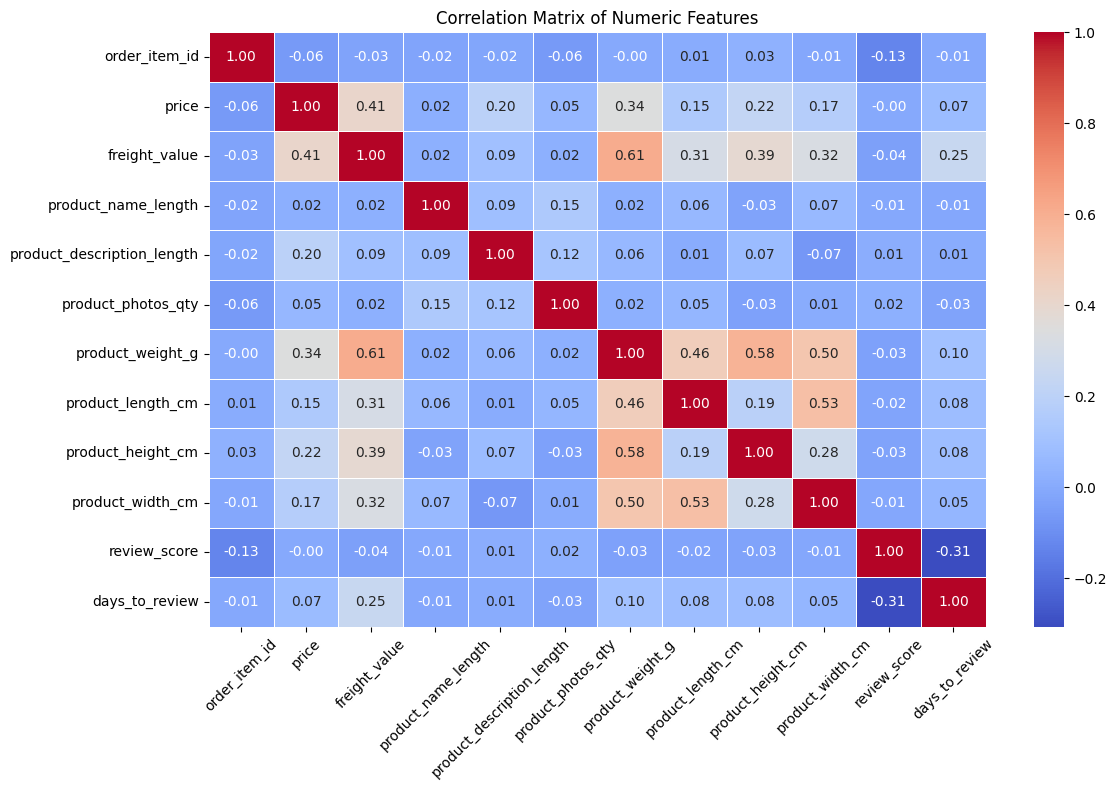

In [18]:
# Examine correlation matrix

# Select only numeric columns
numeric_cols = olist_cleaned_df.select_dtypes(include=['float64', 'int64', 'timedelta64[ns]'])
correlation_matrix = numeric_cols.corr()

# heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### The correlation matrix reveals that freight cost is strongly tied to product weight, and moderately linked to item dimensions and price. Price itself has only a weak relationship with other features, suggesting it's influenced by more than just size or weight. The Review Score is slightly negatively correlated with how long it took customers to leave their review (review_score vs days_to_review), hinting that delayed reviewers tend to be more critical. The physical product attributes (length, width, height, weight) are moderately correlated with each other but not redundant. Overall, the dataset looks clean and usable, with no major red flags or obvious multicollinearity issues so far.

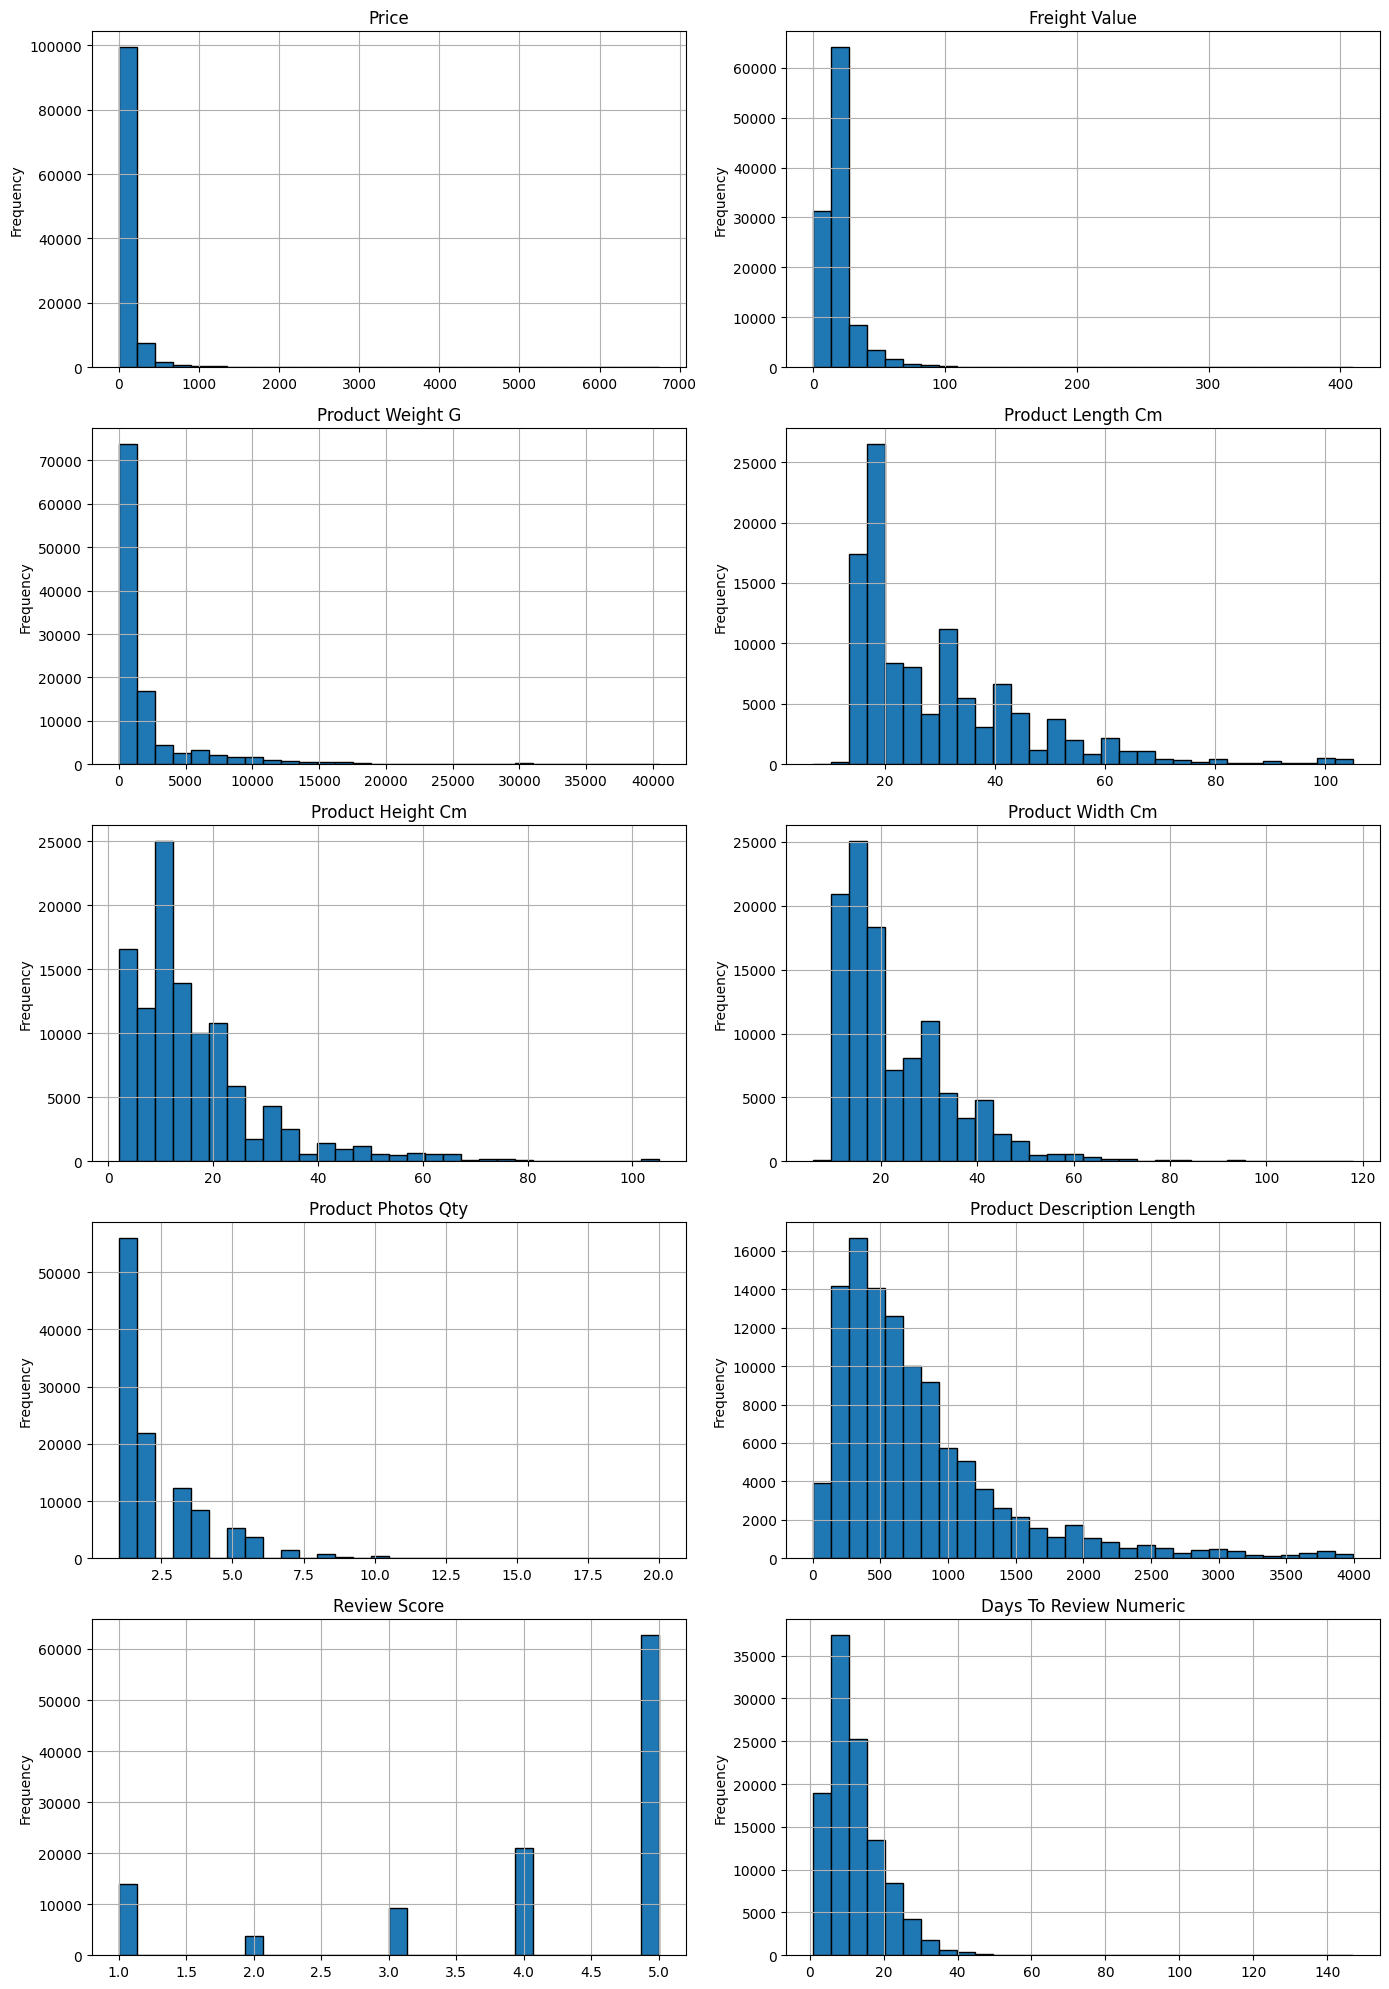

In [19]:
# Histograms to start

if 'days_to_review_numeric' not in olist_cleaned_df.columns:
    olist_cleaned_df['days_to_review_numeric'] = olist_cleaned_df['days_to_review'].dt.days

# Confirm correct columns again
selected_columns_cleaned = [
    'price', 'freight_value', 'product_weight_g',
    'product_length_cm', 'product_height_cm', 'product_width_cm',
    'product_photos_qty', 'product_description_length', 'review_score', 'days_to_review_numeric'
]

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
axes = axes.flatten()

# Plot histograms for each selected column
for i, col in enumerate(selected_columns_cleaned):
    olist_cleaned_df[col].dropna().hist(bins=30, ax=axes[i], edgecolor="black")
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()



### Most numeric features in the dataset are heavily right-skewed, meaning the majority of products are small, light, and cheap—with a long tail of outliers. Review scores show a clear bias toward 5-star ratings, with relatively few low ratings. The review scores are mostly positive, with a small peak at the 1-star value, indicating heavy dissatisfaction with a minority of the products.

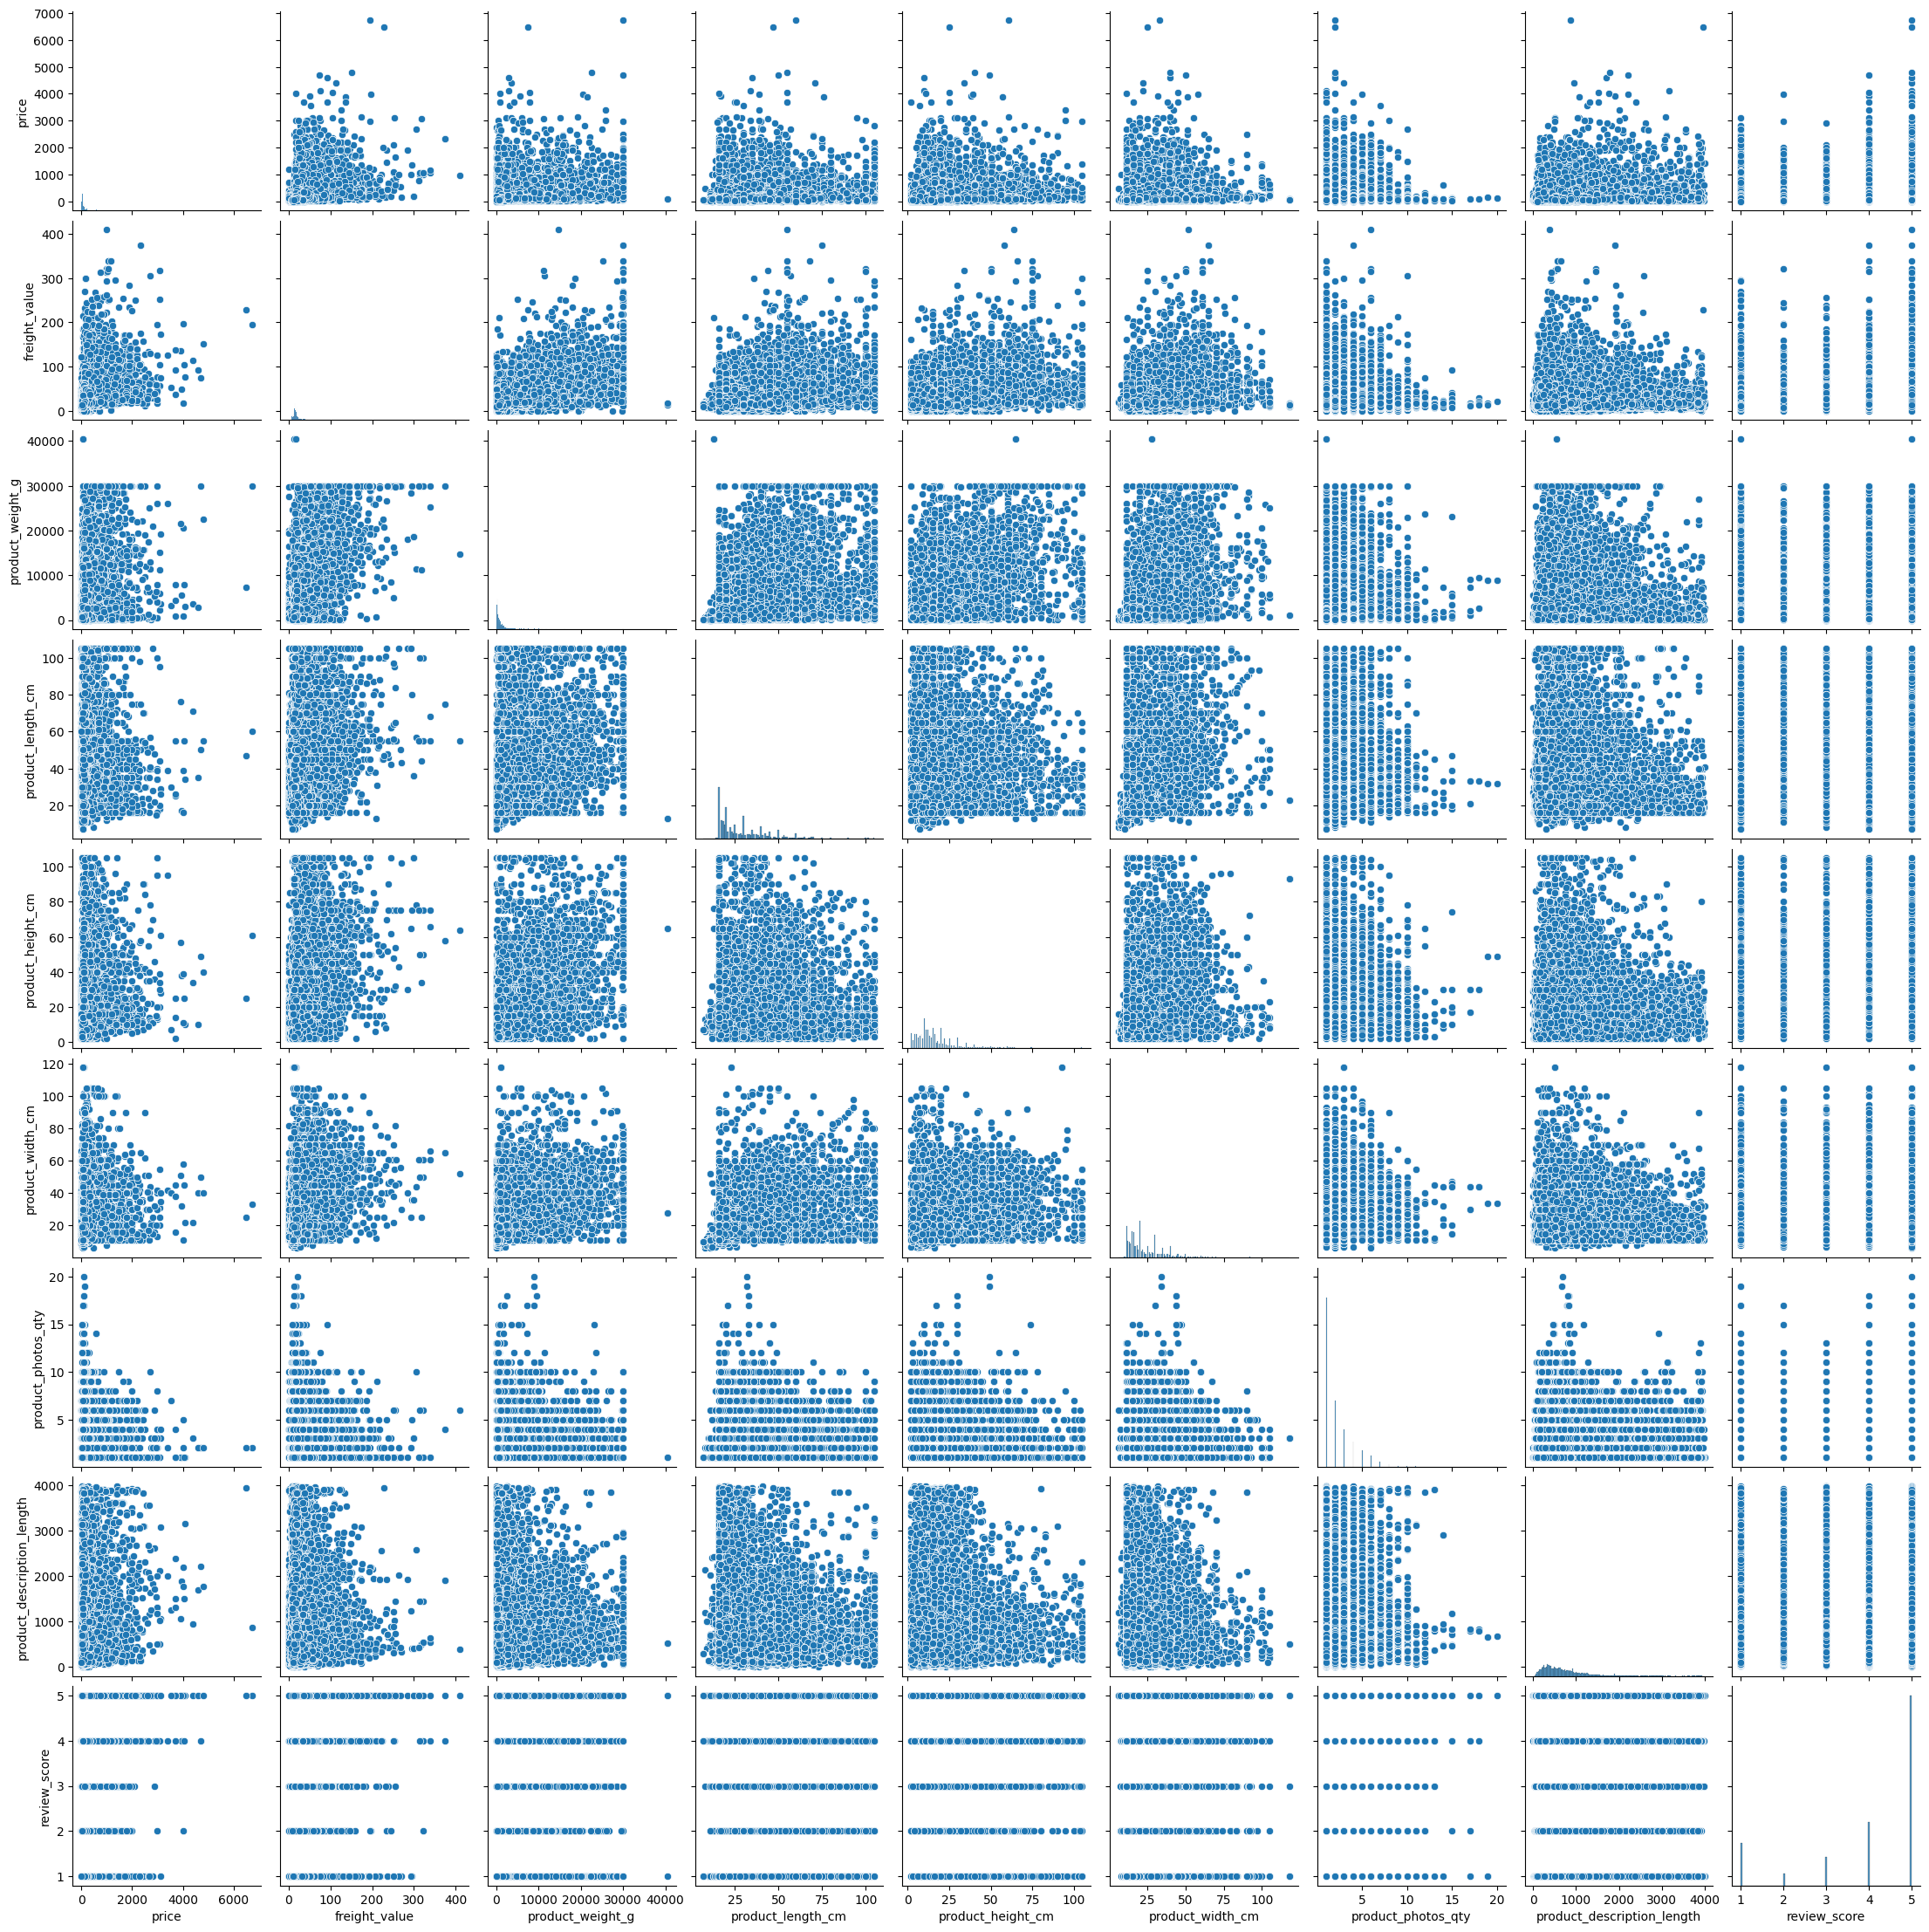

In [24]:
# Draw Pairplots
selected_columns = [
    'price', 'freight_value', 'product_weight_g',
    'product_length_cm', 'product_height_cm', 'product_width_cm',
    'product_photos_qty', 'product_description_length', 'review_score', 'days_to_review'
]

# Create the pairplot using the full dataset (no hue)
pairplot_fig = sns.pairplot(olist_cleaned_df[selected_columns])

# Display the plot
plt.show()

### The data shows somwhat positive relationships (i guess - maybe remove this) between product weight, size, and freight cost—heavier, bulkier items cost more to ship. Most numerical features are heavily right-skewed, especially price and freight value, meaning a few expensive outliers dominate. Review scores, being discrete from 1 to 5, show no clear linear relationship with any other numeric variables. Overall, customer satisfaction doesn’t appear to be strongly influenced by measurable product characteristics in this datasThere's a hard vertical cutoff right at 30000g for product_weight_g, suggesting either a platform constraint or a shipping policy limit in the Olist system. No products go beyond that, which likely reflects business rule.

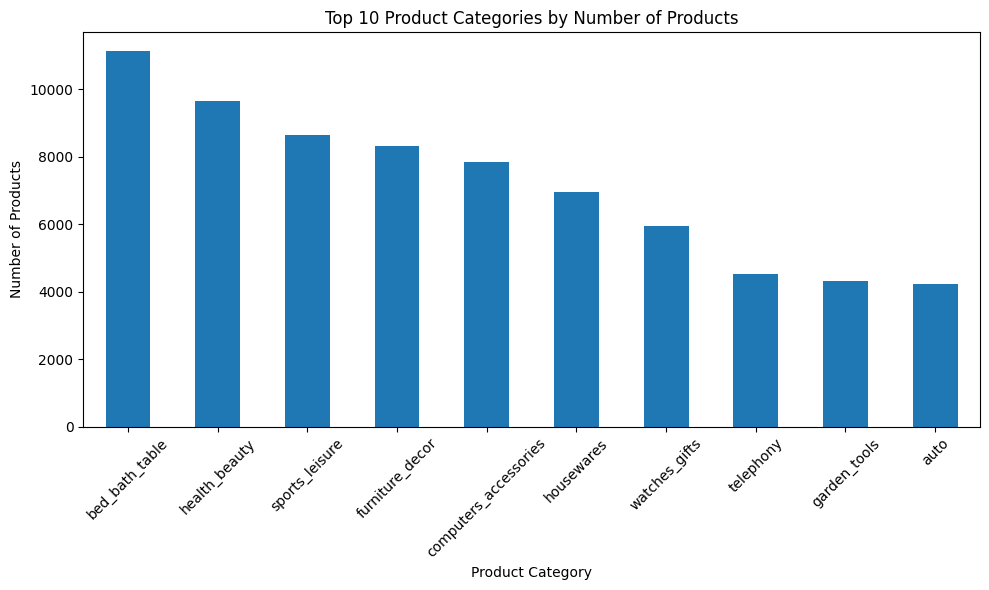

In [27]:
# number of products vs category


# Get top 10 categories by product count
top_10_categories = olist_cleaned_df['product_category_name_english'].value_counts().head(10)

# Plotting
plt.figure(figsize=(10, 6))
top_10_categories.plot(kind='bar')
plt.title('Top 10 Product Categories by Number of Products')
plt.xlabel('Product Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### This bar chart shows that bed_bath_table is the most common category, with over 11,000 listings. It's followed closely by health_beauty, sports_leisure, and furniture_decor, all of which also have high product counts. Categories like telephony, garden_tools, and auto are in the bottom of the top 10, each with just over 4,000 items. The distribution reflects a consumer focus on home, personal care, and lifestyle essentials. Overall, this gives a clear picture of where the bulk of product variety lies in the Olist marketplace.

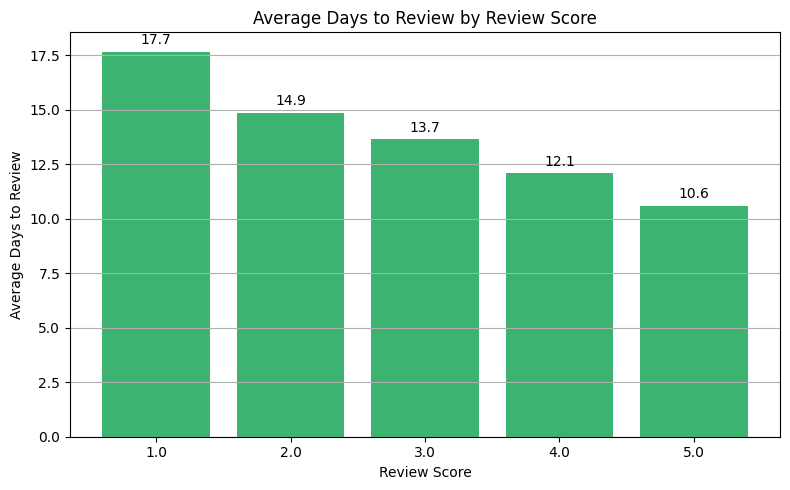

In [36]:
# Group by review_score and calculate average days to review
avg_days_by_score = olist_cleaned_df.groupby('review_score')['days_to_review_numeric'].mean().dropna()

# Plot bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(avg_days_by_score.index.astype(str), avg_days_by_score.values, color='mediumseagreen')

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.2, f'{yval:.1f}', ha='center', va='bottom')

# Label and style
ax.set_title('Average Days to Review by Review Score')
ax.set_xlabel('Review Score')
ax.set_ylabel('Average Days to Review')
ax.grid(axis='y')
plt.tight_layout()
plt.show()


### There’s a clear inverse relationship between review score and review timing - lower ratings are left significantly later than higher ratings. This pattern implies that happier customers tend to provide feedback faster.

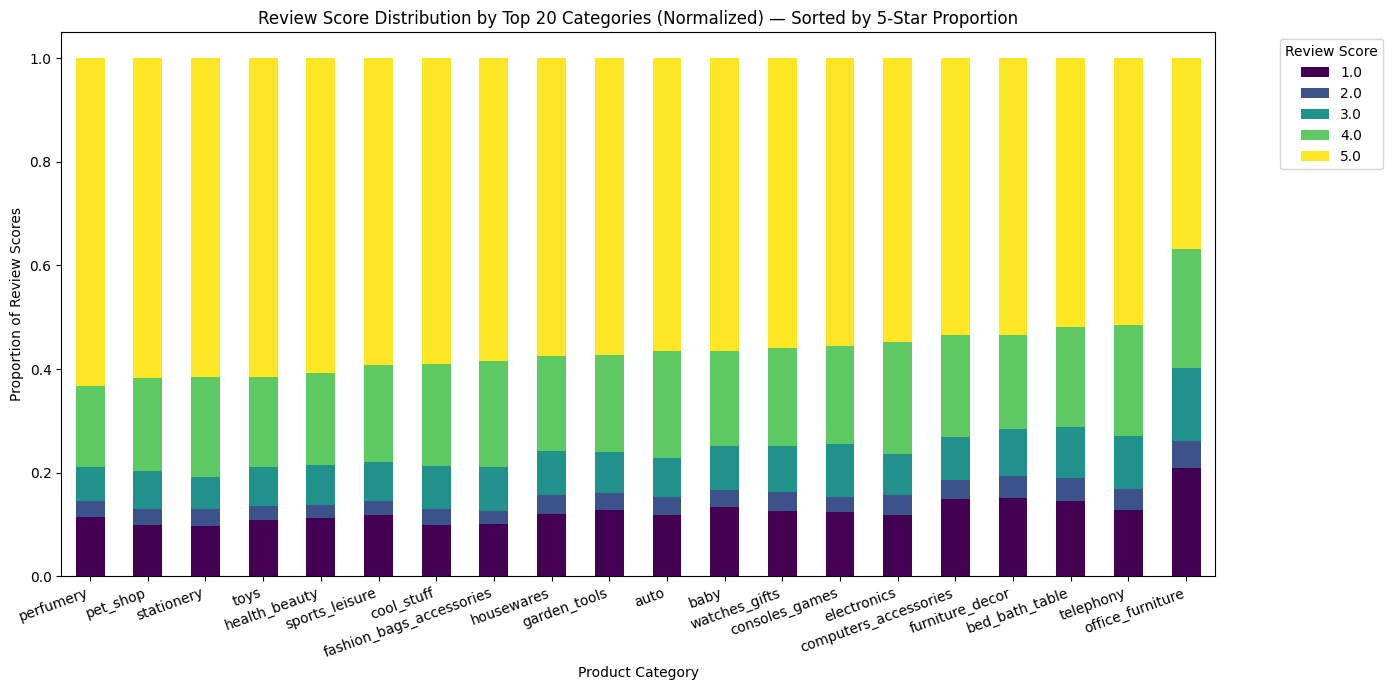

In [53]:
# Identify top 20 categories by review count
top_categories = (
    olist_cleaned_df['product_category_name_english']
    .value_counts()
    .nlargest(20)
    .index
)

# Subset the data to those categories
filtered_df = olist_cleaned_df[
    olist_cleaned_df['product_category_name_english'].isin(top_categories)
]

# Crosstab of review scores per category
score_counts = pd.crosstab(
    filtered_df['product_category_name_english'],
    filtered_df['review_score']
)

# Normalize counts to proportions
score_props = score_counts.div(score_counts.sum(axis=1), axis=0)

# Sort categories by highest proportion of 5-star reviews
sorted_categories = score_props[5].sort_values(ascending=False).index
score_props = score_props.loc[sorted_categories]

# Plot stacked bar chart
score_props.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='viridis'
)
plt.title("Review Score Distribution by Top 20 Categories (Normalized) — Sorted by 5-Star Proportion")
plt.xlabel("Product Category")
plt.ylabel("Proportion of Review Scores")
plt.legend(title="Review Score", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### This stacked bar chart shows how customer satisfaction — measured by review scores — is distributed across the top 20 product categories. Categories like perfumery, pet_shop, and stationery have the highest proportion of 5-star reviews, suggesting strong customer approval. As we move right, categories like telephony and especially office_furniture show a noticeable drop in 5-star ratings, with a growing share of 1- to 3-star reviews. The normalization helps highlight relative satisfaction within each category, regardless of total review volume. Overall, the chart makes it easy to spot which product categories consistently exceed expectations and which ones may be falling short.

/var/folders/pl/w8_gtks92n9flgwzrb6qkssr0000gn/T/ipykernel_883/3048103096.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  olist_cleaned_df.groupby('weight_bin')['review_score']


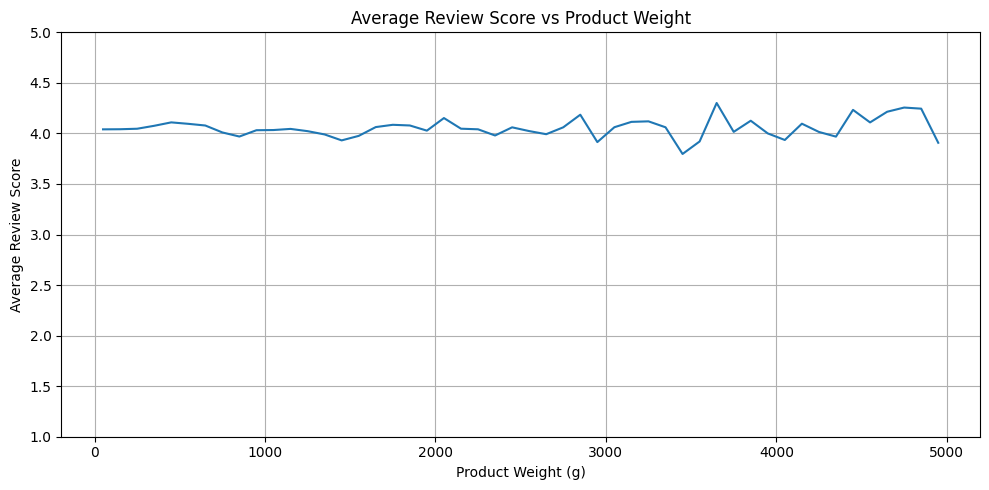

In [61]:
# Average review score (y) vs product weight (x) line chart
# # Bin product weights to reduce noise and outliers
bins = range(0, 5001, 100)  # e.g., 0g to 5000g in 100g intervals
olist_cleaned_df['weight_bin'] = pd.cut(olist_cleaned_df['product_weight_g'], bins)

# Group by weight bin and calculate average review score
weight_score = (
    olist_cleaned_df.groupby('weight_bin')['review_score']
    .mean()
    .reset_index()
    .dropna()
)

# Convert bin labels to numeric midpoints for plotting
weight_score['weight_mid'] = weight_score['weight_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(weight_score['weight_mid'], weight_score['review_score'])
plt.xlabel("Product Weight (g)")
plt.ylabel("Average Review Score")
plt.title("Average Review Score vs Product Weight")
plt.grid(True)
plt.ylim(1, 5)
plt.tight_layout()
plt.show()


### Despite a wide range of product weights, the average review score remains fairly stable around 4.0, suggesting product weight has little influence on customer satisfaction. Minor dips and peaks at higher weights might reflect small sample sizes or niche products.

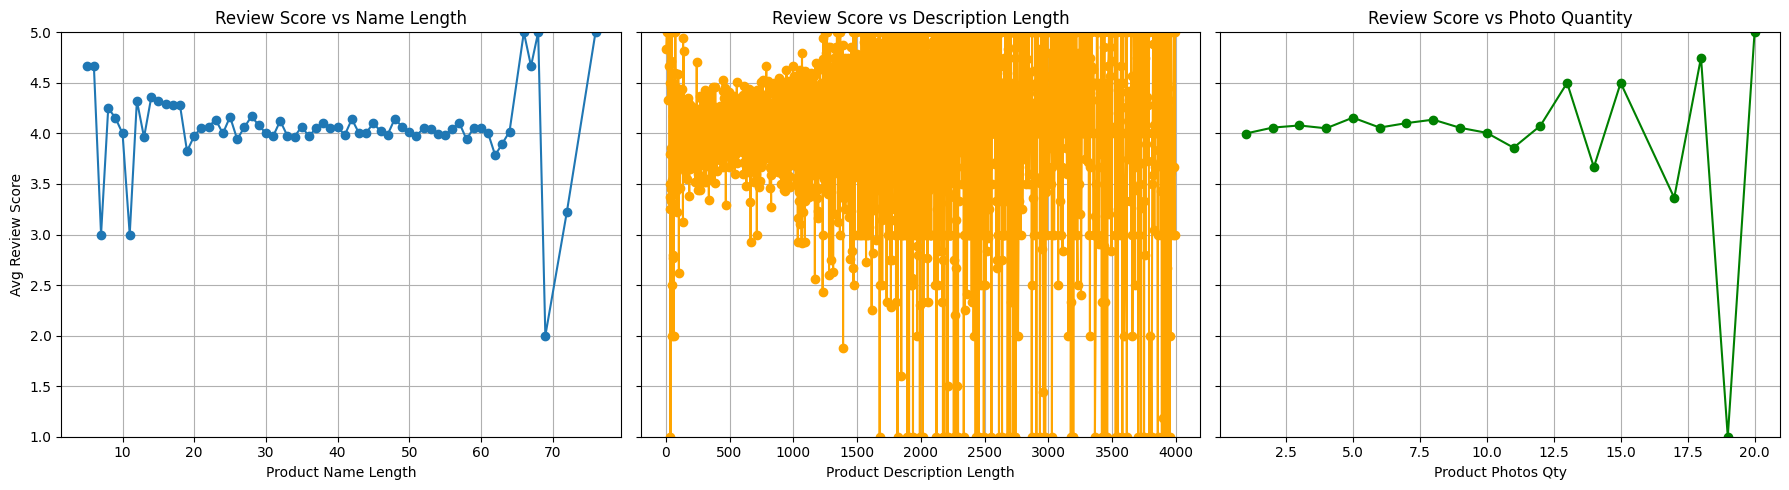

In [67]:
# review score vs product_name_length line chart, product_description_length line chart, product_description_length line chart

# Drop rows with missing values in the relevant columns
df = olist_cleaned_df.dropna(subset=[
    'review_score',
    'product_name_length',
    'product_description_length',
    'product_photos_qty'
])

# Group by raw values, calculate mean review score
name_grouped = df.groupby('product_name_length')['review_score'].mean()
desc_grouped = df.groupby('product_description_length')['review_score'].mean()
photo_grouped = df.groupby('product_photos_qty')['review_score'].mean()

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Subplot 1: Name length
axs[0].plot(name_grouped.index, name_grouped.values, marker='o')
axs[0].set_title('Review Score vs Name Length')
axs[0].set_xlabel('Product Name Length')
axs[0].set_ylabel('Avg Review Score')
axs[0].grid(True)

# Subplot 2: Description length
axs[1].plot(desc_grouped.index, desc_grouped.values, marker='o', color='orange')
axs[1].set_title('Review Score vs Description Length')
axs[1].set_xlabel('Product Description Length')
axs[1].grid(True)

# Subplot 3: Photo quantity
axs[2].plot(photo_grouped.index, photo_grouped.values, marker='o', color='green')
axs[2].set_title('Review Score vs Photo Quantity')
axs[2].set_xlabel('Product Photos Qty')
axs[2].grid(True)

# Y-axis scale
for ax in axs:
    ax.set_ylim(1, 5)

plt.tight_layout()
plt.show()


### Products with name lengths between 20 and 50 characters tend to receive the most consistently high average review scores, suggesting there's a sweet spot for clarity and appeal. The plot for description length is extremely noisy, likely due to the high cardinality of values — averaging over sparse values produces erratic results, making trends hard to interpret. That said, review scores don’t appear to dramatically increase with longer descriptions, indicating that verbosity alone doesn’t drive satisfaction. For product photo quantity, average review scores are fairly stable between 1–10 photos, with a slight increase peaking around 13–15 photos before dropping off. Overall, richer media (photos) may offer a modest improvement in reviews, but overdoing it or relying solely on long descriptions isn’t a guaranteed boost.

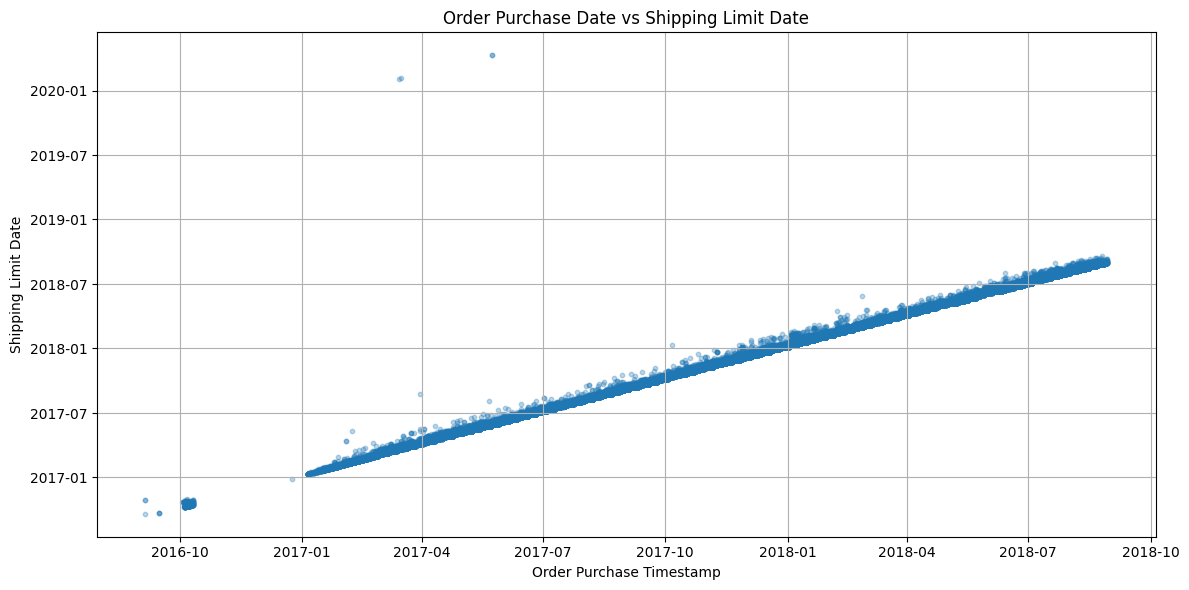

In [ ]:
# order_purchase_timestamp vs shipping_limit_date
# # Ensure datetime conversion
olist_cleaned_df['order_purchase_timestamp'] = pd.to_datetime(olist_cleaned_df['order_purchase_timestamp'], errors='coerce')
olist_cleaned_df['shipping_limit_date'] = pd.to_datetime(olist_cleaned_df['shipping_limit_date'], errors='coerce')

# Drop NaNs for plotting
scatter_df = olist_cleaned_df.dropna(subset=['order_purchase_timestamp', 'shipping_limit_date'])


# Create scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(scatter_df['order_purchase_timestamp'], scatter_df['shipping_limit_date'], alpha=0.3, s=10)
plt.xlabel('Order Purchase Timestamp')
plt.ylabel('Shipping Limit Date')
plt.title('Order Purchase Date vs Shipping Limit Date')
plt.grid(True)
plt.tight_layout()
plt.show()


### This plot shows a tight linear band between order purchase dates and their corresponding shipping deadlines, suggesting that Olist uses a mostly fixed time buffer for shipping - probably a set number of days added to each purchase. The consistent slope indicates that this policy hasn't changed much over time. However, the scattered points above the band show occasional exceptions—orders given much longer shipping limits than the norm. These could reflect bulk orders, pre-orders, or system errors. Overall, this is strong evidence of a standardized shipping SLA.

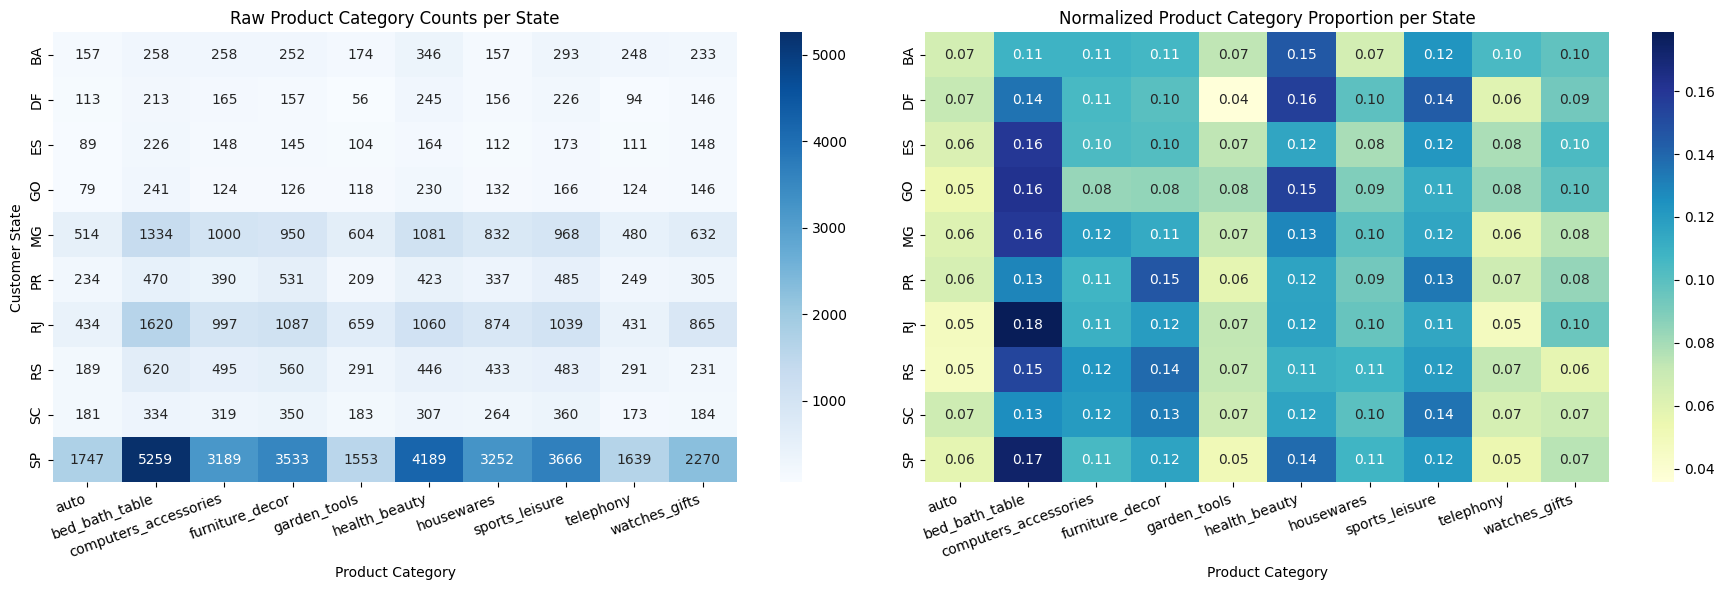

In [ ]:
# analyze product category demand by state

# Filter top 10 states and categories
top_states = olist_cleaned_df['customer_state'].value_counts().head(10).index
top_categories = olist_cleaned_df['product_category_name_english'].value_counts().head(10).index

# Filter the dataset
filtered_df = olist_cleaned_df[
    olist_cleaned_df['customer_state'].isin(top_states) &
    olist_cleaned_df['product_category_name_english'].isin(top_categories)
]

# Create cross-tabulation (raw counts)
crosstab_counts = pd.crosstab(
    filtered_df['customer_state'], 
    filtered_df['product_category_name_english']
)

# Normalize by row (i.e., proportion within each state)
crosstab_normalized = crosstab_counts.div(crosstab_counts.sum(axis=1), axis=0)

# Sort both by state ascending
crosstab_counts = crosstab_counts.sort_index()
crosstab_normalized = crosstab_normalized.sort_index()

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap 1: Raw counts
sns.heatmap(crosstab_counts, annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set_title('Raw Product Category Counts per State')
axs[0].set_xlabel('Product Category')
axs[0].set_ylabel('Customer State')
plt.xticks(rotation= 20)
# Heatmap 2: Normalized
sns.heatmap(crosstab_normalized, annot=True, fmt='.2f', cmap='YlGnBu', ax=axs[1])
axs[1].set_title('Normalized Product Category Proportion per State')
axs[1].set_xlabel('Product Category')
axs[1].set_ylabel('')
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=20, ha="right")
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()



### This pair of heatmaps compares raw product category counts by customer state with their normalized proportions. The left chart shows Sao Paulo (SP) as the dominant consumer across all categories, probaby due to its large population and economy. However, the right chart reveals more nuanced regional preferences once category counts are normalized within each state. For example, DF and GO have a disproportionate preference for health_beauty products, while SC leans more toward sports_leisure. The normalization also shows that all states have little to no demand for auto, garden_tools, telephone, and watches_gift. This likely indicates niche or low-priority segments in Olist’s market, regardless of state size or overall volume

# Olist Dataset Conclusions

## Conclusions
### The dataset appears fully-comprehensive, with reasonable distribution and balance across product categories, review scores, and timestamps. Review behavior and product metadata are in line with expectations = higher scores are more common and left faster, and categories like bed_bath_table dominate the catalog. There’s no immediate indication that there are critical gaps, making this dataset suitable for deeper analysis and modeling.

## Outliers
### Yes, some clear outliers are present. A few records show extreme shipping delays or unusually long product descriptions (above 3000 characters) that deviate sharply from the bulk distribution. Similarly, some photo and dimension metrics (e.g. products with >20 photos or massive weights) stand out and could skew models if not capped or treated properly.


## Highly Correlated Variables
### The correlation matrix shows strong relationships between some physical product dimensions - specifically weight, width, height, and length - which is expected as these often scale together. Freight value and price are also moderately correlated. In modeling scenarios, it may be worth applying dimensionality reduction or choosing a representative feature among these.


## Time-Based Trends
### While the dataset doesn't explicitly chart variables over time (e.g., price or review score drift), the order-purchase vs. shipping-limit scatter suggests stable behavior with few anomalies. There's no strong evidence of concept drift in customer behavior or logistics over time, meaning temporal comparisons are likely still valid.


## Possible Confounding Variables
### Category type is a likely confounder across several relationships. For example, higher review scores correlate weakly with shorter review times and slightly with physical dimensions, but these may be influenced by the product category or customer state. Similarly, normalized category demand by state reveals patterns that could be driven by regional preferences or logistics networks rather than inherent product quality.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

In [ ]:
# Storytelling with data Pg 95. Fig. 3.21

# fake data 
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
received = [160, 180, 240, 150, 180, 165, 140, 200, 160, 140, 150, 175]
processed = [160, 180, 235, 150, 180, 155, 135, 160, 130, 110, 130, 145]

# plot the fake data
plt.figure(figsize=(10, 5))
plt.plot(months, received, label='Ticket Volume Received', color='steelblue', linewidth=3)
plt.plot(months, processed, label='Ticket Volume Processed', color='brown', linewidth=3)

# max 300
plt.ylim(0, 300)

# format the axis and graph
plt.title("Storytelling with data graph reproduction Pg 95. Fig. 3.21")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False, fontsize=12)
plt.tight_layout()
plt.show()
